[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Daniel-534/IntroduccionAstronomiaPractica/blob/main/Tama%C3%B1osMovimientosAparentesPlanetas/Practica6_Tama%C3%B1osMovimientosAparentesPlanetas.ipynb)

In [9]:
!pip install astroquery astropy -q

# Práctica 6: Tamaños y Movimientos Aparentes de los Planetas
## Análisis computacional con `astroquery` y NASA/JPL Horizons

---

**Curso:** Introducción a la Astronomía Práctica  
**Herramientas:** Python 3 · `astroquery` · `astropy` · `matplotlib` · `pandas` · `numpy`  
**Base de datos:** NASA/JPL Horizons System — https://ssd.jpl.nasa.gov/horizons/

---

> *«¿Por qué sabemos que la Tierra orbita alrededor del Sol y no al contrario?»*  
> — Enunciado de la Práctica 6

En lugar del seguimiento manual con **Stellarium**, esta práctica consulta directamente el sistema **JPL Horizons** de la NASA mediante la biblioteca `astroquery` (Ginsburg et al., 2019). JPL Horizons integra numéricamente las ecuaciones de movimiento de todo el Sistema Solar usando las efemérides DE440/DE441 (Park et al., 2021) con precisión de ~1 mas (milisegundo de arco). Es el mismo sistema utilizado por misiones como Cassini, New Horizons y el James Webb Space Telescope para la planificación de observaciones.

### Ventajas frente a Stellarium

| Aspecto | Stellarium | `astroquery` + JPL Horizons |
|---------|-----------|------------------------------|
| Fuente de datos | Base de datos VSOP87 interna | Integraciones numéricas DE440 |
| Precisión posicional | ~1″ | ~1 mas |
| Reproducibilidad | Manual / capturas de pantalla | 100 % automático y trazable |
| Análisis cuantitativo | Lectura visual de valores | Python completo (numpy, pandas…) |
| Acceso programático | No | Sí (API pública de NASA) |

### Referencias principales

| Clave | Referencia |
|-------|-----------|
| **Karttunen+ 2007** | Karttunen et al. (2007). *Fundamental Astronomy*, 5ª ed. Springer. |
| **Portilla 2001** | Portilla Barbosa, J. G. (2001). *Elementos de Astronomía de Posición*. UNAL. |
| **Park+ 2021** | Park, R. S. et al. (2021). The JPL Planetary and Lunar Ephemerides DE440 and DE441. *AJ*, 161(3), 105. https://doi.org/10.3847/1538-4365-161-3-105 |
| **Ginsburg+ 2019** | Ginsburg, A. et al. (2019). Astroquery: An Astronomical Web-querying Package in Python. *AJ*, 157(3), 98. https://doi.org/10.3847/1538-3881/aafc33 |
| **Galilei 1610** | Galilei, G. (1610). *Sidereus Nuncius*. Tommaso Baglioni, Venecia. |
| **Williams 2023** | Williams, D. R. (2023). *Planetary Fact Sheet*. NASA/GSFC. https://nssdc.gsfc.nasa.gov/planetary/factsheet/ |


In [10]:
# Instalar dependencias si es necesario:
# !pip install astroquery astropy matplotlib pandas numpy

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
from astropy.time import Time
import astropy.units as u
from astroquery.jplhorizons import Horizons

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'figure.figsize': (12, 5),
})

print('Librerías importadas correctamente.')
print('  astroquery para consultar JPL Horizons (NASA)')
print('  astropy para manejo de tiempo astronómico y unidades')


Librerías importadas correctamente.
  astroquery para consultar JPL Horizons (NASA)
  astropy para manejo de tiempo astronómico y unidades


---
## 1. JPL Horizons y `astroquery`: la herramienta de trabajo

El sistema **JPL Horizons** (Jet Propulsion Laboratory, NASA) es una base de datos de efemérides planetarias de acceso libre que cubre ~1.3 millones de objetos del Sistema Solar. Para cada objeto puede calcularse, en cualquier fecha entre el año −9999 y el +9999:

- Posición (AR y Dec aparentes, con corrección de aberración y precesión)
- Distancia al observador ($\Delta$) y al Sol ($r$)
- Tamaño angular aparente (`ang_width`)
- Fracción iluminada del disco (`illumination`)
- Elongación solar (`elong`)
- Ángulo de fase ($\alpha$: ángulo Sol–objeto–observador)
- Magnitud visual aparente ($V$)

En Python, la clase `Horizons` de `astroquery.jplhorizons` permite hacer estas consultas con tres parámetros principales:

```python
from astroquery.jplhorizons import Horizons

objeto = Horizons(
    id = 299,          # Código NAIF (299 = Venus, 499 = Marte)
    location = '500',  # '500' = geocentro de la Tierra
    epochs = {
        'start': 'YYYY-MM-DD',
        'stop':  'YYYY-MM-DD',
        'step':  'Nd'           # N días entre observaciones
    }
)
tabla = objeto.ephemerides()    # Devuelve astropy.QTable
```

> **Fuente:** Ginsburg et al. (2019), §3.4; documentación oficial: https://astroquery.readthedocs.io/en/latest/jplhorizons/jplhorizons.html


---
## 2. Período Orbital Sinódico

### Marco teórico

El **período sidéreo** ($P$) es el tiempo real de revolución de un planeta alrededor del Sol, medido respecto a las estrellas de fondo. Como la Tierra también orbita, lo que puede medirse directamente desde ella es el **período sinódico** ($P_{\text{syn}}$): el intervalo entre dos configuraciones geométricas idénticas consecutivas (p. ej., de conjunción a conjunción, u oposición a oposición).

Comparando las velocidades angulares medias $\omega = 2\pi/P$:

$$\omega_{\text{syn}} = |\omega_{\text{planeta}} - \omega_\oplus| \implies \frac{1}{P_{\text{syn}}} = \left|\frac{1}{P_{\text{planeta}}} - \frac{1}{P_\oplus}\right|$$

Según la posición relativa:

- **Planeta inferior** ($P_{\text{planeta}} < P_\oplus$, órbita interna, más veloz):
$$\frac{1}{P_{\text{syn}}} = \frac{1}{P_{\text{planeta}}} - \frac{1}{P_\oplus}$$

- **Planeta superior** ($P_{\text{planeta}} > P_\oplus$, órbita externa, más lento):
$$\frac{1}{P_{\text{syn}}} = \frac{1}{P_\oplus} - \frac{1}{P_{\text{planeta}}}$$

> **Fuentes:** Portilla (2001), Cap. 4, ecs. (4.1)–(4.3); Karttunen et al. (2007), §3.1.


In [11]:
# Períodos siderales en días
# Fuente: Williams, D. R. (2023). Planetary Fact Sheet. NASA/GSFC.
# https://nssdc.gsfc.nasa.gov/planetary/factsheet/

P_sid = {
    'Mercurio':  87.97,
    'Venus':    224.70,
    'Tierra':   365.25,
    'Marte':    686.97,
    'Jupiter': 4332.59,
    'Saturno': 10759.22,
    'Urano':   30688.5,
    'Neptuno':  60182.0,
}

P_tierra = P_sid['Tierra']

print(f"{'Planeta':<10} {'Tipo':<10} {'P_sid (dias)':>14} {'P_syn (dias)':>14} {'P_syn (meses)':>14}")
print('-' * 65)

resultados_syn = {}
for planeta, P in P_sid.items():
    if planeta == 'Tierra':
        continue
    tipo = 'inferior' if P < P_tierra else 'superior'
    if P < P_tierra:
        P_syn = 1.0 / (1.0/P - 1.0/P_tierra)
    else:
        P_syn = 1.0 / (1.0/P_tierra - 1.0/P)
    resultados_syn[planeta] = P_syn
    print(f"{planeta:<10} {tipo:<10} {P:>14.2f} {P_syn:>14.2f} {P_syn/30.44:>14.2f}")

print(f"\n>> Periodo sinotico de Venus: {resultados_syn['Venus']:.2f} dias  ")
print(f"   ({resultados_syn['Venus']/365.25:.2f} años)")
print(f">> Periodo sinotico de Marte: {resultados_syn['Marte']:.2f} dias  ")
print(f"   ({resultados_syn['Marte']/30.44:.1f} meses)")


Planeta    Tipo         P_sid (dias)   P_syn (dias)  P_syn (meses)
-----------------------------------------------------------------
Mercurio   inferior            87.97         115.88           3.81
Venus      inferior           224.70         583.93          19.18
Marte      superior           686.97         779.92          25.62
Jupiter    superior          4332.59         398.88          13.10
Saturno    superior         10759.22         378.09          12.42
Urano      superior         30688.50         369.65          12.14
Neptuno    superior         60182.00         367.48          12.07

>> Periodo sinotico de Venus: 583.93 dias  
   (1.60 años)
>> Periodo sinotico de Marte: 779.92 dias  
   (25.6 meses)


---
## 3. Venus: Fases y Tamaño Angular Aparente

### Marco teórico

#### Geometría orbital de Venus

Venus es un **planeta inferior**: su órbita está completamente contenida dentro de la de la Tierra ($a_V = 0.723$ UA, $a_\oplus = 1.000$ UA). Esto genera dos consecuencias observacionales decisivas:

1. **Fases completas** — Venus puede presentar cualquier fracción iluminada, desde «lleno» hasta prácticamente invisible, análogamente a la Luna.
2. **Variación dramática del tamaño angular** — su distancia geocéntrica $\Delta$ oscila entre $\approx 0.27$ UA (conjunción inferior) y $\approx 1.72$ UA (conjunción superior), lo que produce una variación de tamaño angular de casi **1:6**:

$$\theta = \frac{d_{\text{Venus}}}{\Delta} \approx \frac{12\,104 \text{ km}}{\Delta}$$

#### Configuraciones principales

| Configuración | Posición | $\Delta$ (aprox.) | Iluminación | $\theta$ (aprox.) |
|--------------|----------|-------------------|-------------|-------------------|
| Conjunción superior | Venus detrás del Sol | 1.72 UA | ~100 % (lleno) | ~10" |
| Elongación máxima | Venus a máx. 47° del Sol | ~0.72 UA | ~50 % (cuarto) | ~25" |
| Conjunción inferior | Venus delante del Sol | 0.27 UA | ~0 % (nueva) | ~64" |

#### La prueba heliocéntrica de Galileo (1610)

En noviembre de 1610, Galileo observó con su telescopio que Venus mostraba **fases completas** y que su tamaño aparente **variaba inversamente** con su iluminación (Galilei, 1610). Esto era incompatible con el modelo geocéntrico de Ptolomeo:

- **Modelo geocéntrico (Ptolomeo)**: Venus siempre está entre la Tierra y el Sol. Su tamaño debería ser casi constante y nunca podría aparecer «lleno». ✗
- **Modelo heliocéntrico (Copérnico/Kepler)**: Venus orbita el Sol. En conjunción superior está lejos y lleno; en conjunción inferior está cerca y como creciente delgado. ✓

#### Ángulo de fase $\alpha$ y fracción iluminada $k$

El **ángulo de fase** $\alpha$ es el ángulo Sol–Venus–Tierra. La fracción iluminada $k$ vista desde la Tierra es:

$$k = \frac{1 + \cos\alpha}{2}$$

- $\alpha = 0°$ → $k = 1$ (lleno, conjunción superior)
- $\alpha = 90°$ → $k = 0.5$ (cuarto, elongación máxima)
- $\alpha = 180°$ → $k = 0$ (nueva, conjunción inferior)

> **Fuentes:** Karttunen et al. (2007), §3.3–3.4 y §7.1; Galilei (1610); Van Helden, A. (1989). *Sidereus Nuncius or the Sidereal Messenger*. Univ. of Chicago Press; Portilla (2001), §4.1–4.2.


In [13]:
# Consulta de efemérides de Venus al JPL Horizons
# Rango: ~608 dias ~ 1.04 periodos sinodicos
# Cubre la conjuncion inferior de Venus del 13 de agosto de 2023 completamente.
# Paso: 5 dias
#
# id=299         -> Venus (codigo NAIF del JPL)
# location='500' -> Observador en el geocentro de la Tierra
#
# Referencia: Park et al. (2021), DE440/DE441 ephemeris.

print('Consultando JPL Horizons para Venus (2022-06-01 a 2024-03-01)...')
print('Requiere conexion a internet. Por favor espere.\n')

venus_q = Horizons(
    id=299,
    location='500',
    epochs={
        'start': '2022-06-01',
        'stop':  '2024-03-01',
        'step':  '5d'
    }
)
eph_v = venus_q.ephemerides()

df_v = eph_v.to_pandas()

t_v = Time(df_v['datetime_jd'].values, format='jd')
df_v['date']      = t_v.datetime
df_v['decimalyr'] = t_v.decimalyear

# Elongacion con signo: + = oriental (estrella vespertina, E del Sol)
#                       - = occidental (estrella matutina, O del Sol)
# elongFlag: 'L' = leading = E del Sol; 'T' = trailing = O del Sol
if 'elongFlag' in df_v.columns:
    flag = df_v['elongFlag'].str.strip()
    df_v['elong_signed'] = df_v['elong'] * np.where(flag == 'L', 1.0, -1.0)
else:
    df_v['elong_signed'] = df_v['elong']

print(f'OK: {len(df_v)} efemerides obtenidas.')
print(f'  Rango: {df_v["date"].iloc[0].strftime("%Y-%m-%d")} '
      f'-> {df_v["date"].iloc[-1].strftime("%Y-%m-%d")}')
print(f'\nColumnas principales disponibles:')
cols_interes = ['datetime_str','RA','DEC','delta','r','illumination','ang_width','elong','alpha','V']
print('  ' + ', '.join(c for c in cols_interes if c in df_v.columns))
print(f'\nPrimeras filas:')
print(df_v[[c for c in cols_interes if c in df_v.columns][:8]].head(4).to_string(index=False))


Consultando JPL Horizons para Venus (2022-06-01 a 2024-03-01)...
Requiere conexion a internet. Por favor espere.

OK: 128 efemerides obtenidas.
  Rango: 2022-06-01 -> 2024-02-26

Columnas principales disponibles:
  datetime_str, RA, DEC, delta, r, illumination, ang_width, elong, alpha, V

Primeras filas:
     datetime_str       RA      DEC    delta        r  illumination  ang_width   elong
2022-Jun-01 00:00 32.11816 10.85452 1.219376 0.727708      77.83958   13.68601 36.5900
2022-Jun-06 00:00 37.78291 12.79800 1.252418 0.727366      79.30611   13.32494 35.5027
2022-Jun-11 00:00 43.54724 14.63686 1.284636 0.726945      80.72721   12.99075 34.3874
2022-Jun-16 00:00 49.42083 16.34747 1.316003 0.726455      82.10272   12.68111 33.2455


In [14]:
# Tabla 6.1 (version digital): Registro de observaciones de Venus
# Submuestra cada ~60 dias (paso bimestral) para replicar el procedimiento del enunciado.
# Fuente de datos: NASA/JPL Horizons (Park et al., 2021).

step_bimestral = max(1, round(60 / 5))   # 60 dias / paso 5 dias = 12
idx_sel = list(range(0, len(df_v), step_bimestral))

cols_tabla = ['date', 'illumination', 'ang_width', 'elong', 'alpha', 'delta', 'r', 'V']
tabla61 = df_v[cols_tabla].iloc[idx_sel].copy().reset_index(drop=True)
tabla61.columns = [
    'Fecha',
    'Iluminado (%)',
    'Diam. aparente (")',
    'Elong. (deg)',
    'Fase alpha (deg)',
    'Dist. Tierra Delta (UA)',
    'Dist. Sol r (UA)',
    'Mag. V'
]
tabla61['Fecha'] = tabla61['Fecha'].dt.strftime('%Y-%m-%d')
tabla61.index += 1

# Verificar k teorico con la formula k = (1 + cos(alpha))/2
alpha_rad = np.radians(df_v.loc[df_v.index[idx_sel], 'alpha'].values)
k_teorico = (1 + np.cos(alpha_rad)) / 2 * 100

pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 130)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

print('Tabla 6.1 - Registro digital de observaciones de Venus')
print('Fuente: NASA/JPL Horizons (Park et al., 2021)\n')
print(tabla61.to_string())
print()
print('Verificacion: Iluminado(%) medido vs. calculado con k = (1 + cos(alpha))/2 x 100')
h1, h2, h3, h4 = 'Fecha', 'Medido (%)', 'Teorico (%)', 'Error (%)'
print(f'  {h1:<12} {h2:>12} {h3:>13} {h4:>11}')
for i, (med, teo) in enumerate(zip(tabla61['Iluminado (%)'].values, k_teorico)):
    print(f'  {tabla61["Fecha"].iloc[i]:<12} {med:>12.1f} {teo:>13.1f} {abs(med-teo):>11.2f}')


Tabla 6.1 - Registro digital de observaciones de Venus
Fuente: NASA/JPL Horizons (Park et al., 2021)

         Fecha  Iluminado (%)  Diam. aparente (")  Elong. (deg)  Fase alpha (deg)  Dist. Tierra Delta (UA)  Dist. Sol r (UA)  Mag. V
1   2022-06-01          77.84               13.69         36.59             56.16                     1.22              0.73   -3.95
2   2022-07-31          92.37               10.76         22.14             32.07                     1.55              0.72   -3.88
3   2022-09-29          99.39                9.78          6.41              8.94                     1.71              0.72   -3.92
4   2022-11-28          98.85                9.91          9.02             12.29                     1.68              0.73   -3.91
5   2023-01-27          92.31               10.98         23.16             32.21                     1.52              0.73   -3.90
6   2023-03-28          78.65               13.71         36.21             55.04                   

### Análisis gráfico de Venus

Los tres gráficos siguientes deben leerse de forma integrada:

1. **Diámetro angular e iluminación vs. tiempo** — muestra la anti-correlación temporal directa.
2. **Diámetro angular vs. fracción iluminada** — la *huella dactilar* del modelo heliocéntrico; imposible de replicar con el modelo geocéntrico de Ptolomeo.
3. **Elongación solar, iluminación y distancia vs. tiempo** — demuestra que Venus siempre está próximo al Sol en el cielo ($\leq 47°$) y relaciona su visibilidad con su fase y distancia.

> **Fuentes:** Portilla (2001), Cap. 4; Karttunen et al. (2007), §3.3.


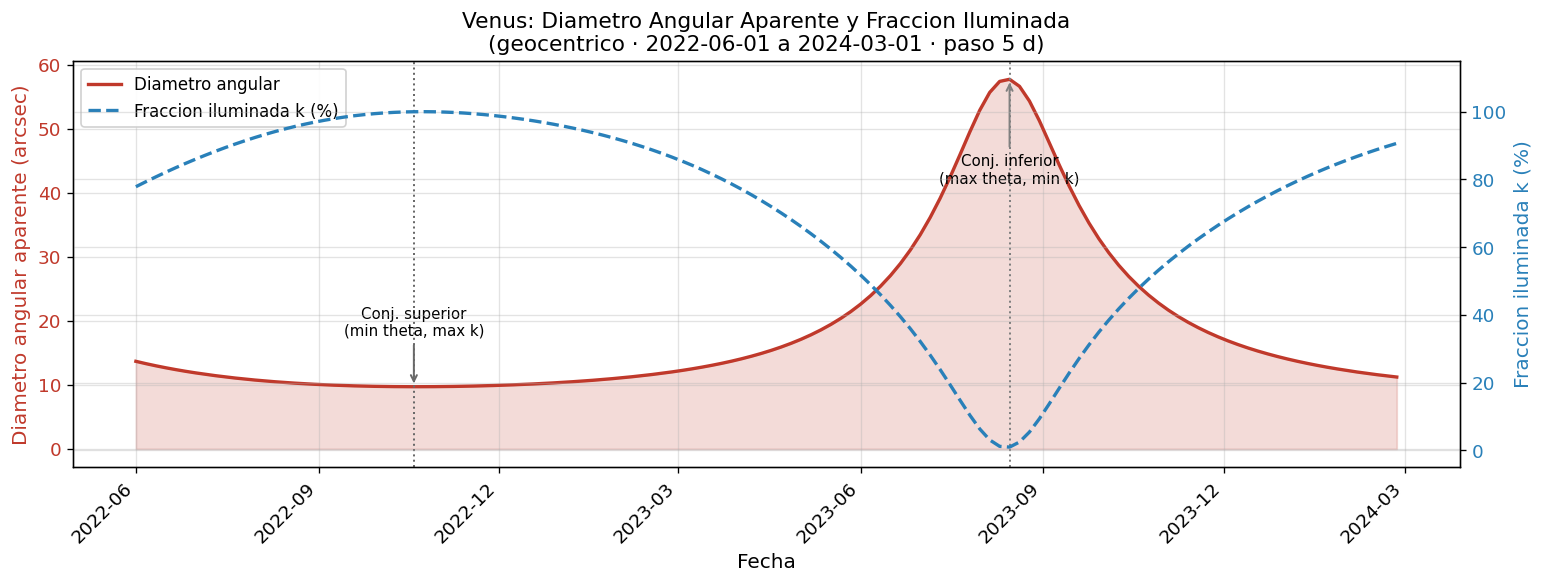

Fuente de datos: NASA/JPL Horizons (Park et al., 2021)


In [15]:
# GRAFICO 1: Diametro angular aparente y fraccion iluminada vs. tiempo
# Muestra la anti-correlacion: Venus grande <-> poco iluminado, y viceversa.
# Fuente datos: NASA/JPL Horizons (Park et al., 2021).

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

c_diam  = '#c0392b'
c_illum = '#2980b9'

ax1.fill_between(df_v['date'], df_v['ang_width'], alpha=0.18, color=c_diam)
ax1.plot(df_v['date'], df_v['ang_width'], color=c_diam, lw=2.0,
         label='Diametro angular')

ax2.plot(df_v['date'], df_v['illumination'], color=c_illum, lw=2.0,
         linestyle='--', label='Fraccion iluminada k (%)')
ax2.set_ylim(-5, 115)

# Marcar conjuncion inferior (max diametro)
idx_ic = df_v['ang_width'].idxmax()
d_ic   = df_v.loc[idx_ic, 'date']
y_ic   = df_v.loc[idx_ic, 'ang_width']
ax1.axvline(d_ic, color='gray', lw=1.2, linestyle=':')
ax1.annotate('Conj. inferior\n(max theta, min k)',
             xy=(d_ic, y_ic), xytext=(d_ic, y_ic * 0.72),
             ha='center', fontsize=9,
             arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))

# Marcar conjuncion superior (min diametro)
idx_sc = df_v['ang_width'].idxmin()
d_sc   = df_v.loc[idx_sc, 'date']
y_sc   = df_v.loc[idx_sc, 'ang_width']
ax1.axvline(d_sc, color='dimgray', lw=1.2, linestyle=':')
ax1.annotate('Conj. superior\n(min theta, max k)',
             xy=(d_sc, y_sc), xytext=(d_sc, y_sc + 8),
             ha='center', fontsize=9,
             arrowprops=dict(arrowstyle='->', color='dimgray', lw=1.2))

ax1.set_ylabel('Diametro angular aparente (arcsec)', color=c_diam)
ax1.tick_params(axis='y', labelcolor=c_diam)
ax2.set_ylabel('Fraccion iluminada k (%)', color=c_illum)
ax2.tick_params(axis='y', labelcolor=c_illum)
ax1.set_xlabel('Fecha')

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

lines1, lab1 = ax1.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lab1 + lab2, loc='upper left', framealpha=0.9)

ax1.set_title('Venus: Diametro Angular Aparente y Fraccion Iluminada\n'
              '(geocentrico · 2022-06-01 a 2024-03-01 · paso 5 d)', fontsize=13)
plt.tight_layout()
plt.savefig('venus_diametro_iluminacion_vs_tiempo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fuente de datos: NASA/JPL Horizons (Park et al., 2021)')


#### Interpretación — Gráfico 1

El gráfico muestra una **anti-correlación sistemática** entre $\theta$ y $k$:

- **Conjunción inferior**: $\theta$ máximo (~60–64"), $k$ mínimo (~0 %). Venus está cerca pero iluminado por detrás: se ve como un creciente delgado y enorme.
- **Conjunción superior**: $\theta$ mínimo (~10–11"), $k$ máximo (~100 %). Venus está lejos pero completamente iluminado.

La variación de **casi 1:6 en tamaño angular** durante un período sinódico es proporcional a la variación en distancia geocéntrica $\Delta$, de acuerdo con la ley de perspectiva $\theta \propto 1/\Delta$.

**¿Por qué esto rechaza el modelo geocéntrico?**  
En el modelo de Ptolomeo, Venus siempre orbita entre la Tierra y el Sol. Su distancia varía poco y *nunca* podría aparecer «lleno». Lo observado —variación enorme en tamaño **y** fases completas— es *incompatible* con el geocentrismo ptolemaico. (Portilla, 2001, Cap. 4; Karttunen+ 2007, §3.3)


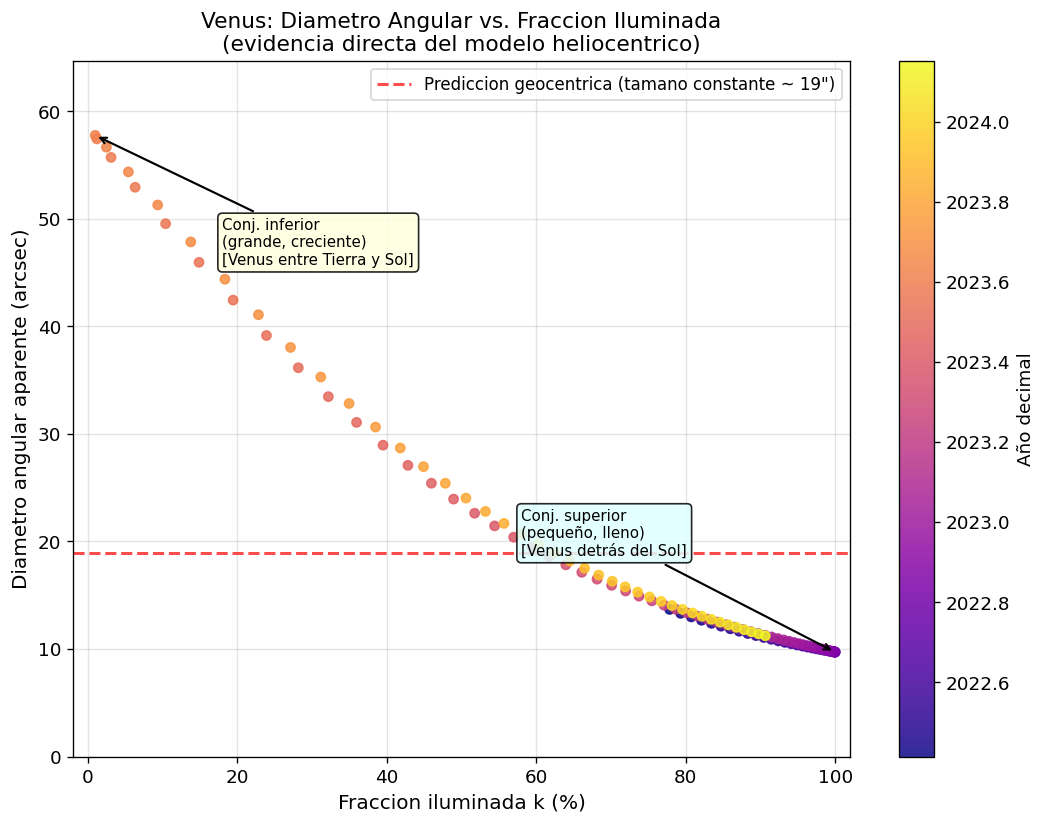

Fuente de datos: NASA/JPL Horizons (Park et al., 2021)


In [16]:
# GRAFICO 2: Diametro angular vs. fraccion iluminada
# ESTE ES EL GRAFICO CENTRAL DE LA PRACTICA.
# La trayectoria en este espacio es una firma del modelo helioecentrico.
# En el modelo geocentrico de Ptolomeo, los puntos formarian una nube horizontal
# (tamano constante para todas las fases). Los datos reales muestran una curva
# inclinada de pendiente NEGATIVA, rechazando el geocentrismo.
# Fuente datos: NASA/JPL Horizons (Park et al., 2021).

fig, ax = plt.subplots(figsize=(9, 7))

norm = Normalize(vmin=df_v['decimalyr'].min(), vmax=df_v['decimalyr'].max())
cmap = plt.cm.plasma
sc   = ax.scatter(df_v['illumination'], df_v['ang_width'],
                  c=df_v['decimalyr'], cmap=cmap, s=30, alpha=0.85, zorder=3)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Año decimal', fontsize=11)

# Prediccion geocentrica: tamano constante (linea horizontal)
media_theta = df_v['ang_width'].mean()
ax.axhline(media_theta, color='red', lw=1.8, linestyle='--', alpha=0.7,
           label=f'Prediccion geocentrica (tamano constante ~ {media_theta:.0f}")')

# Anotar conjuncion inferior
idx_ic = df_v['ang_width'].idxmax()
ax.annotate(
    'Conj. inferior\n(grande, creciente)\n[Venus entre Tierra y Sol]',
    xy=(df_v.loc[idx_ic,'illumination'], df_v.loc[idx_ic,'ang_width']),
    xytext=(18, df_v['ang_width'].max() - 12),
    fontsize=9, ha='left',
    arrowprops=dict(arrowstyle='->', color='k', lw=1.3),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.85)
)

# Anotar conjuncion superior
idx_sc = df_v['ang_width'].idxmin()
ax.annotate(
    'Conj. superior\n(pequeño, lleno)\n[Venus detrás del Sol]',
    xy=(df_v.loc[idx_sc,'illumination'], df_v.loc[idx_sc,'ang_width']),
    xytext=(58, df_v['ang_width'].min() + 9),
    fontsize=9, ha='left',
    arrowprops=dict(arrowstyle='->', color='k', lw=1.3),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightcyan', alpha=0.85)
)

ax.set_xlabel('Fraccion iluminada k (%)', fontsize=12)
ax.set_ylabel('Diametro angular aparente (arcsec)', fontsize=12)
ax.set_title(
    'Venus: Diametro Angular vs. Fraccion Iluminada\n'
    '(evidencia directa del modelo heliocentrico)', fontsize=13
)
ax.legend(fontsize=10)
ax.set_xlim(-2, 102)
ax.set_ylim(0, df_v['ang_width'].max() * 1.12)

plt.tight_layout()
plt.savefig('venus_diametro_vs_iluminacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fuente de datos: NASA/JPL Horizons (Park et al., 2021)')


#### Interpretación — Gráfico 2 (el gráfico diagnóstico del heliocentrismo)

La trayectoria en el espacio $(\theta, k)$ forma una **curva inclinada**: a mayor iluminación, menor tamaño angular. Esta curva recorre un ciclo completo por período sinódico. La **línea discontinua roja** representa la predicción del modelo geocéntrico: tamaño constante para todas las fases. Los datos reales forman una curva de pendiente *negativa*, **falsando el modelo geocéntrico**.

#### Respuestas a las preguntas del enunciado

**¿Qué representa el parámetro «Iluminado» (`illumination`)?**  
Es la fracción del disco de Venus visible desde la Tierra que está iluminada por el Sol, expresada en porcentaje. Equivale a $k = (1 + \cos\alpha)/2 \times 100\%$, donde $\alpha$ es el ángulo de fase Sol–Venus–Tierra (Karttunen+ 2007, §7.1). La Tabla 6.1 verifica que los valores calculados con esta fórmula coinciden con los de JPL Horizons.

**¿Qué fenómeno es responsable del cambio en ese parámetro?**  
La **geometría de la iluminación solar**: al moverse Venus en su órbita alrededor del Sol, el ángulo Sol–Venus–Tierra cambia continuamente. Es análogo a las fases lunares pero con período ~584 días.

**¿Cómo se relacionan «Iluminado» y «Diámetro aparente»?**  
Se relacionan de forma **inversamente proporcional**: Venus es grande cuando está poco iluminado (cerca de la Tierra, conjunción inferior) y pequeño cuando está muy iluminado (lejos de la Tierra, conjunción superior).

**¿Cómo apoya lo observado al modelo heliocéntrico?**  
El modelo heliocéntrico predice exactamente esta relación: fases completas *y* variación dramática de tamaño. El modelo geocéntrico ptolemaico predice tamaño constante y ausencia de fase «gibosa» o «llena».

**¿Cómo cambiarían las observaciones bajo el geocentrismo?**  
Venus nunca cruzaría el plano Tierra–Sol; sus fases nunca pasarían del cuarto (nunca «lleno»), y su tamaño sería aproximadamente constante (representado por la línea roja discontinua del Gráfico 2).

> **Fuentes:** Karttunen et al. (2007), §3.3; Portilla (2001), Cap. 4; Van Helden (1989), *Sidereus Nuncius*.


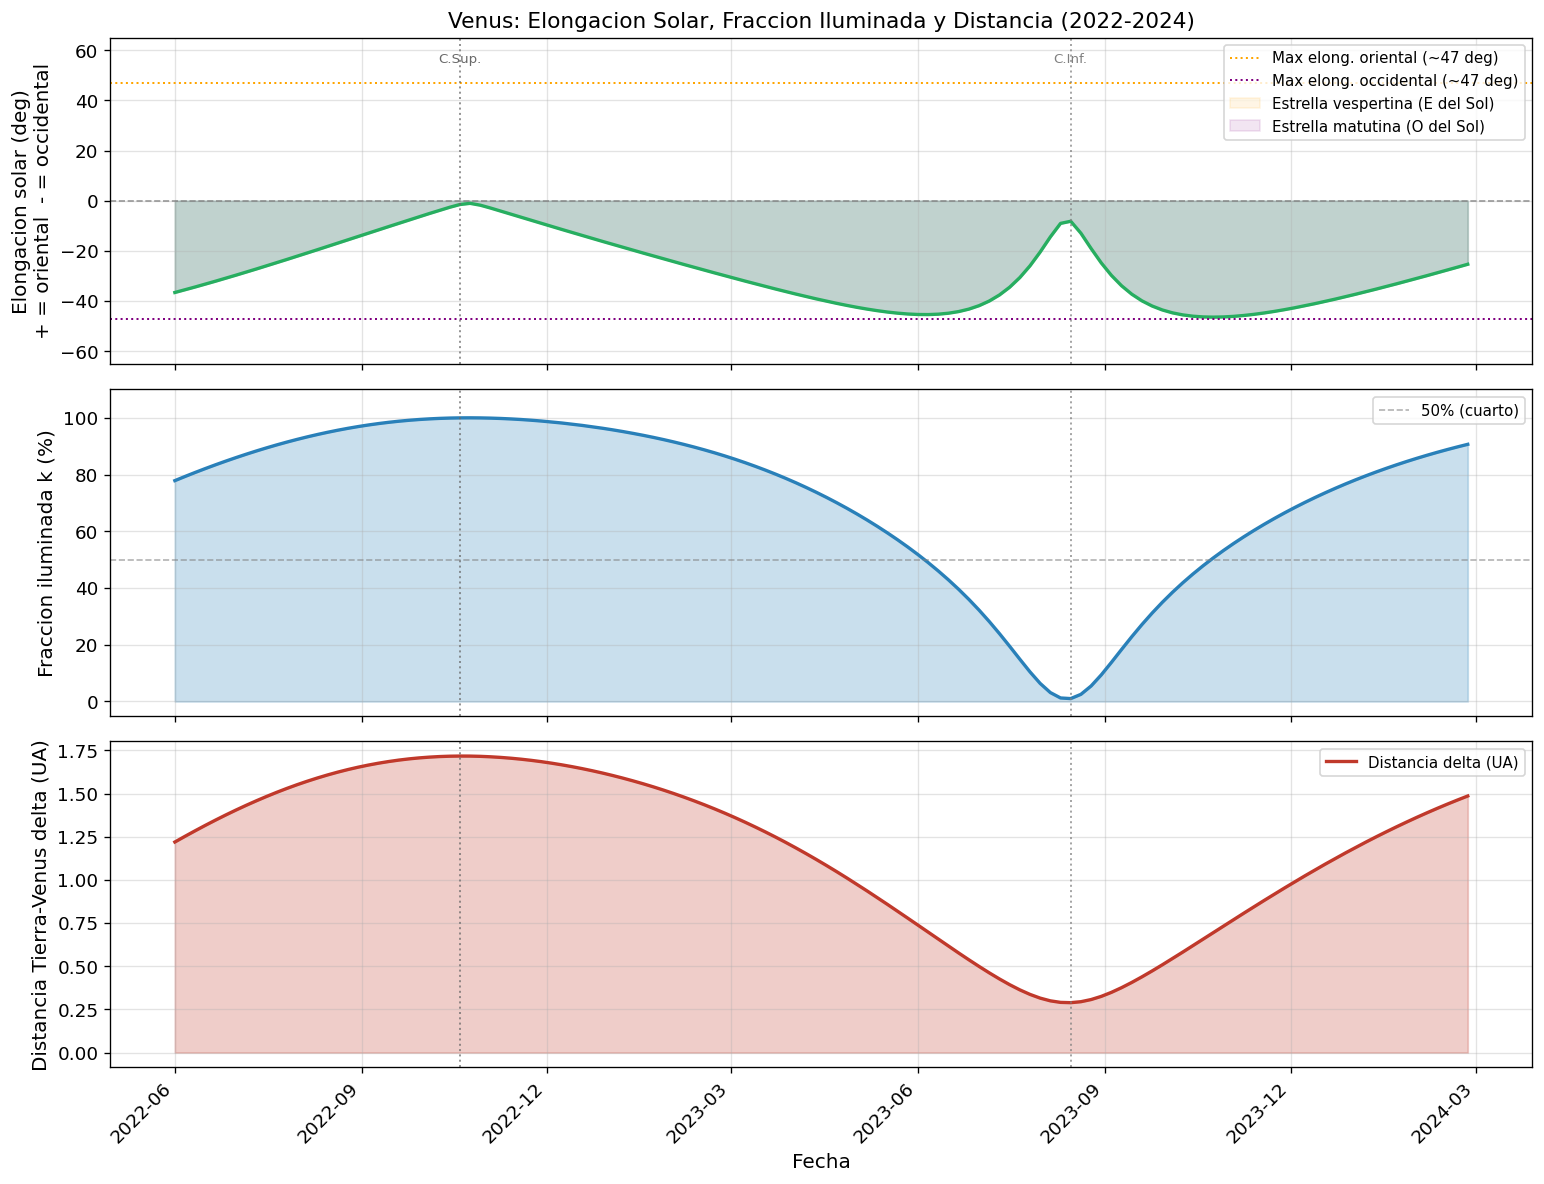

Fuente de datos: NASA/JPL Horizons (Park et al., 2021)


In [17]:
# GRAFICO 3: Elongacion solar (con signo), fraccion iluminada y distancia vs. tiempo
# Muestra que Venus nunca se aleja mas de ~47 grados del Sol en el cielo.
# Fuente datos: NASA/JPL Horizons (Park et al., 2021).

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

# Panel 1: Elongacion con signo
ax = axes[0]
ax.fill_between(df_v['date'], df_v['elong_signed'], alpha=0.25, color='#27ae60')
ax.plot(df_v['date'], df_v['elong_signed'], '#27ae60', lw=2)
ax.axhline(0,   color='gray',   lw=1.0, linestyle='--', alpha=0.8)
ax.axhline( 47, color='orange', lw=1.2, linestyle=':', label='Max elong. oriental (~47 deg)')
ax.axhline(-47, color='purple', lw=1.2, linestyle=':', label='Max elong. occidental (~47 deg)')
ax.fill_between(df_v['date'], df_v['elong_signed'], 0,
                where=df_v['elong_signed'] > 0, alpha=0.10, color='orange',
                label='Estrella vespertina (E del Sol)')
ax.fill_between(df_v['date'], df_v['elong_signed'], 0,
                where=df_v['elong_signed'] < 0, alpha=0.10, color='purple',
                label='Estrella matutina (O del Sol)')
ax.set_ylabel('Elongacion solar (deg)\n+ = oriental  - = occidental')
ax.set_ylim(-65, 65)
ax.legend(loc='upper right', fontsize=9)
ax.set_title('Venus: Elongacion Solar, Fraccion Iluminada y Distancia (2022-2024)', fontsize=13)

# Panel 2: Fraccion iluminada
ax2 = axes[1]
ax2.fill_between(df_v['date'], df_v['illumination'], alpha=0.25, color='#2980b9')
ax2.plot(df_v['date'], df_v['illumination'], '#2980b9', lw=2)
ax2.axhline(50, color='gray', lw=1, linestyle='--', alpha=0.6, label='50% (cuarto)')
ax2.set_ylabel('Fraccion iluminada k (%)')
ax2.set_ylim(-5, 110)
ax2.legend(fontsize=9)

# Panel 3: Distancia geocentrica
ax3 = axes[2]
ax3.fill_between(df_v['date'], df_v['delta'], alpha=0.25, color='#c0392b')
ax3.plot(df_v['date'], df_v['delta'], '#c0392b', lw=2, label='Distancia delta (UA)')
ax3.set_ylabel('Distancia Tierra-Venus delta (UA)')
ax3.set_xlabel('Fecha')
ax3.legend(fontsize=9)

# Marcar conjunciones en todos los paneles
idx_ic = df_v['ang_width'].idxmax()
idx_sc = df_v['ang_width'].idxmin()
for ax_i in axes:
    ax_i.axvline(df_v.loc[idx_ic, 'date'], color='gray',    lw=1.2, linestyle=':', alpha=0.7)
    ax_i.axvline(df_v.loc[idx_sc, 'date'], color='dimgray', lw=1.2, linestyle=':', alpha=0.7)
axes[0].annotate('C.Inf.', xy=(df_v.loc[idx_ic,'date'], 55), fontsize=8, color='gray', ha='center')
axes[0].annotate('C.Sup.', xy=(df_v.loc[idx_sc,'date'], 55), fontsize=8, color='dimgray', ha='center')

axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('venus_elongacion_iluminacion_distancia.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fuente de datos: NASA/JPL Horizons (Park et al., 2021)')


#### Interpretación — Gráfico 3

**Panel superior — Elongación solar:**  
Venus oscila entre $-47°$ y $+47°$ del Sol, *nunca más*. Esto significa que Venus solo puede observarse cerca del horizonte al amanecer (estrella matutina, elongación occidental) o al atardecer (estrella vespertina, elongación oriental). Venus pasa por $0°$ en las conjunciones (alineado con el Sol). La limitación en elongación máxima es una consecuencia directa de que la órbita de Venus es completamente *interior* a la de la Tierra (Portilla, 2001, §4.2).

**Panel central — Fracción iluminada:**  
El ciclo de fases es sinódico: pasa de 0 % a 100 % y vuelve en cada período sinódico (~584 d). Los pasos por el 50 % ocurren cerca de las elongaciones máximas (fase de cuarto), cuando el ángulo de fase $\alpha \approx 90°$.

**Panel inferior — Distancia geocéntrica $\Delta$:**  
La distancia varía entre ~0.27 UA (conjunción inferior) y ~1.72 UA (conjunción superior), una relación 1:6.4 que explica directamente la variación de tamaño angular. La mínima distancia coincide con la mínima fracción iluminada.

> **Fuente:** Karttunen et al. (2007), §3.2–3.3; Portilla (2001), §4.2–4.3.


---
## 4. Marte: Movimiento Retrógrado

### Marco teórico

#### ¿Qué es el movimiento retrógrado?

Desde la Tierra, los planetas generalmente se desplazan de **Oeste a Este** sobre el fondo estelar (movimiento **directo** o **progrado**), en el mismo sentido que el Sol a lo largo de la eclíptica. Sin embargo, los **planetas superiores** (Marte, Júpiter, Saturno…) periódicamente *parecen detenerse y retroceder* de Este a Oeste durante semanas; luego reanudan su movimiento directo. Esto se denomina **movimiento retrógrado**.

#### Explicación geométrica (modelo heliocéntrico)

El movimiento retrógrado es un **efecto de perspectiva** causado por la velocidad diferencial de los planetas en sus órbitas. La Tierra orbita el Sol más rápido que Marte ($v_\oplus \approx 29.8$ km/s, $v_{\text{Marte}} \approx 24.1$ km/s). Cerca de la **oposición** (Marte a 180° del Sol), la Tierra se adelanta a Marte. Durante esas semanas, la dirección desde la Tierra hacia Marte se desplaza hacia el Oeste respecto a las estrellas: el movimiento aparente de Marte se invierte.

El proceso completo es:

1. **Pre-retrógrado**: Marte se mueve hacia el Este (AR creciente)
2. **Primer punto estacionario**: $\mathrm{d(AR)/dt} = 0$, antes de la oposición
3. **Retrogradación**: Marte se mueve hacia el Oeste (AR decreciente); centrada en la oposición
4. **Segundo punto estacionario**: $\mathrm{d(AR)/dt} = 0$, después de la oposición
5. **Post-retrógrado**: Marte retoma movimiento hacia el Este

La retrogradación de Marte dura típicamente **60–82 días** y ocurre cerca de cada oposición (~cada 26 meses, su período sinódico).

#### La oposición de Marte 2027

La oposición del ciclo 2026–2027 ocurre alrededor del **19 de febrero de 2027**. En esa fecha: Marte está a su mínima distancia geocéntrica (diámetro angular *máximo*), está a 180° del Sol (visible *toda la noche*), y la retrogradación ya habrá comenzado antes (~diciembre 2026) y terminará después (~abril 2027).

#### Nota histórica

En el modelo geocéntrico de **Ptolomeo** (siglo II d.C.), el movimiento retrógrado se explicaba haciendo girar al planeta sobre un **epiciclo** (círculo pequeño cuyo centro recorre un deferente). El modelo heliocéntrico de Copérnico–Kepler explica el mismo fenómeno con la mecánica orbital sin necesidad de epiciclos, como efecto puramente geométrico de las órbitas concéntricas.

> **Fuentes:** Karttunen et al. (2007), §3.2; Portilla (2001), §4.3–4.4; Dreyer, J. L. E. (1906). *A History of Astronomy from Thales to Kepler*. Cambridge Univ. Press.


In [18]:
# Consulta de efemérides de Marte al JPL Horizons
# Rango: 1 año completo desde el 1 de septiembre de 2026 (según el enunciado).
# Paso: 10 dias.
# La oposicion de Marte ocurre aproximadamente el 19 de febrero de 2027.
#
# id=499         -> Marte (codigo NAIF)
# location='500' -> Geocentro de la Tierra
# Fuente: Park et al. (2021).

print('Consultando JPL Horizons para Marte (2026-09-01 a 2027-09-01)...')
print('Requiere conexion a internet. Por favor espere.\n')

mars_q = Horizons(
    id=499,
    location='500',
    epochs={
        'start': '2026-09-01',
        'stop':  '2027-09-01',
        'step':  '10d'
    }
)
eph_m = mars_q.ephemerides()

df_m = eph_m.to_pandas()

t_m = Time(df_m['datetime_jd'].values, format='jd')
df_m['date']      = t_m.datetime
df_m['decimalyr'] = t_m.decimalyear

# Calcular dRA/dt para identificar retrogradacion
jd_vals = df_m['datetime_jd'].values
ra_vals = df_m['RA'].values

dra = np.diff(ra_vals)
dra[dra >  180] -= 360   # correccion de wrapping
dra[dra < -180] += 360

dra_dt = dra / np.diff(jd_vals)          # grados/dia
dra_dt = np.append(dra_dt, dra_dt[-1])   # extender al ultimo punto

df_m['dRA_dt'] = dra_dt
df_m['retro']  = dra_dt < 0              # True = retrogrado

print(f'OK: {len(df_m)} efemerides de Marte obtenidas.')
print(f'  Rango: {df_m["date"].iloc[0].strftime("%Y-%m-%d")} '
      f'-> {df_m["date"].iloc[-1].strftime("%Y-%m-%d")}')
print(f'\nColumnas disponibles:')
cols_m = ['datetime_str','RA','DEC','delta','r','illumination','ang_width','elong','alpha','V']
print('  ' + ', '.join(c for c in cols_m if c in df_m.columns))
print(f'\nPrimeras filas:')
print(df_m[['date','RA','DEC','delta','ang_width','elong']].head(5).to_string(index=False))


Consultando JPL Horizons para Marte (2026-09-01 a 2027-09-01)...
Requiere conexion a internet. Por favor espere.

OK: 37 efemerides de Marte obtenidas.
  Rango: 2026-09-01 -> 2027-08-27

Columnas disponibles:
  datetime_str, RA, DEC, delta, r, illumination, ang_width, elong, alpha, V

Primeras filas:
      date     RA   DEC  delta  ang_width  elong
2026-09-01 104.20 23.33   1.85       5.06  55.20
2026-09-11 110.99 22.73   1.79       5.22  58.63
2026-09-21 117.52 21.89   1.73       5.41  62.28
2026-10-01 123.79 20.85   1.67       5.62  66.15
2026-10-11 129.75 19.66   1.59       5.87  70.29


In [19]:
# Identificacion cuantitativa del periodo retrogrado de Marte
# Fuente: Portilla (2001), seccion 4.3; Karttunen et al. (2007), seccion 3.2.

# -- Oposicion: maxima elongacion ------------------------------------------
idx_opp   = df_m['elong'].idxmax()
d_opp     = df_m.loc[idx_opp, 'date']
elong_opp = df_m.loc[idx_opp, 'elong']
theta_opp = df_m.loc[idx_opp, 'ang_width']
delta_opp = df_m.loc[idx_opp, 'delta']

print('=' * 55)
print('  OPOSICION DE MARTE')
print('=' * 55)
print(f'  Fecha:            {d_opp.strftime("%Y-%m-%d")}')
print(f'  Elongacion solar: {elong_opp:.2f} grados')
print(f'  Diametro angular: {theta_opp:.2f} arcsec')
print(f'  Distancia delta:  {delta_opp:.4f} UA  ({delta_opp * 149.6e6:.1f} Mkm)')
print()

# -- Periodos retrogrados ---------------------------------------------------
retro_arr = df_m['retro'].values
starts_r  = np.where(~retro_arr[:-1] & retro_arr[1:])[0] + 1
ends_r    = np.where(retro_arr[:-1] & ~retro_arr[1:])[0] + 1

print('=' * 55)
print('  PERIODOS DE MOVIMIENTO RETROGRADO')
print('=' * 55)
for i, (s, e) in enumerate(zip(starts_r, ends_r)):
    d_start  = df_m['date'].iloc[s]
    d_end    = df_m['date'].iloc[e]
    dur      = (d_end - d_start).days
    ra_s     = df_m['RA'].iloc[s]
    ra_e     = df_m['RA'].iloc[e]
    dra      = ra_e - ra_s
    if dra >  180: dra -= 360
    if dra < -180: dra += 360
    print(f'\n  Periodo {i+1}:')
    print(f'    Inicio retrogrado: {d_start.strftime("%Y-%m-%d")}')
    print(f'    Fin retrogrado:    {d_end.strftime("%Y-%m-%d")}')
    print(f'    Duracion:          {dur} dias  (~{dur/30.44:.1f} meses)')
    print(f'    Delta AR:          {dra:.2f} grados (desplazamiento hacia el Oeste)')
    print(f'    Dias antes de la oposicion:  {(d_opp - d_start).days}')
    print(f'    Dias despues de la oposicion: {(d_end - d_opp).days}')


  OPOSICION DE MARTE
  Fecha:            2027-02-18
  Elongacion solar: 174.96 grados
  Diametro angular: 13.81 arcsec
  Distancia delta:  0.6784 UA  (101484693.0 Mkm)

  PERIODOS DE MOVIMIENTO RETROGRADO

  Periodo 1:
    Inicio retrogrado: 2027-01-09
    Fin retrogrado:    2027-03-30
    Duracion:          80 dias  (~2.6 meses)
    Delta AR:          -18.84 grados (desplazamiento hacia el Oeste)
    Dias antes de la oposicion:  40
    Dias despues de la oposicion: 40


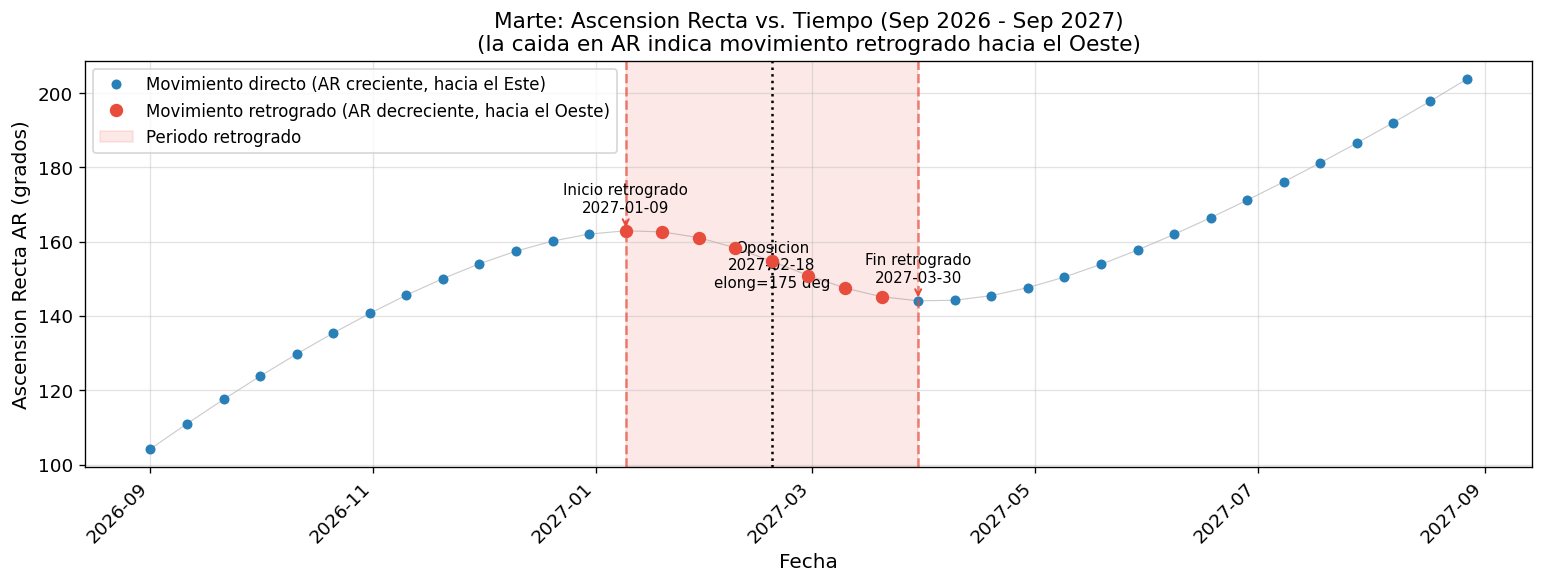

Fuente de datos: NASA/JPL Horizons (Park et al., 2021)


In [20]:
# GRAFICO 4: Ascension Recta de Marte vs. tiempo
# La RA disminuye durante la retrogradacion (movimiento hacia el Oeste).
# Este grafico es la forma mas directa de visualizar el movimiento retrogrado.
# Fuente datos: NASA/JPL Horizons (Park et al., 2021).

fig, ax = plt.subplots(figsize=(13, 5))

retro_mask = df_m['retro'].values

# Movimiento directo (azul)
ax.plot(df_m.loc[~df_m['retro'], 'date'],
        df_m.loc[~df_m['retro'], 'RA'],
        'o', color='#2980b9', markersize=5,
        label='Movimiento directo (AR creciente, hacia el Este)')

# Movimiento retrogrado (rojo)
ax.plot(df_m.loc[df_m['retro'], 'date'],
        df_m.loc[df_m['retro'], 'RA'],
        'o', color='#e74c3c', markersize=7, zorder=5,
        label='Movimiento retrogrado (AR decreciente, hacia el Oeste)')

# Linea de fondo
ax.plot(df_m['date'], df_m['RA'], '-', color='gray', lw=0.7, alpha=0.4, zorder=1)

# Detectar puntos estacionarios y oposicion
starts_r = np.where(~retro_mask[:-1] & retro_mask[1:])[0] + 1
ends_r   = np.where(retro_mask[:-1] & ~retro_mask[1:])[0] + 1

if len(starts_r) > 0:
    idx_s = starts_r[0]
    ax.axvline(df_m['date'].iloc[idx_s], color='#e74c3c', lw=1.5, linestyle='--', alpha=0.7)
    ax.annotate(
        f'Inicio retrogrado\n{df_m["date"].iloc[idx_s].strftime("%Y-%m-%d")}',
        xy=(df_m['date'].iloc[idx_s], df_m['RA'].iloc[idx_s]),
        xytext=(df_m['date'].iloc[idx_s], df_m['RA'].iloc[idx_s] + 5),
        fontsize=9, ha='center',
        arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.2))

if len(ends_r) > 0:
    idx_e = ends_r[0]
    ax.axvline(df_m['date'].iloc[idx_e], color='#e74c3c', lw=1.5, linestyle='--', alpha=0.7)
    ax.annotate(
        f'Fin retrogrado\n{df_m["date"].iloc[idx_e].strftime("%Y-%m-%d")}',
        xy=(df_m['date'].iloc[idx_e], df_m['RA'].iloc[idx_e]),
        xytext=(df_m['date'].iloc[idx_e], df_m['RA'].iloc[idx_e] + 5),
        fontsize=9, ha='center',
        arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.2))

# Oposicion
idx_opp = df_m['elong'].idxmax()
ax.axvline(df_m.loc[idx_opp, 'date'], color='k', lw=1.5, linestyle=':')
ax.annotate(
    f'Oposicion\n{df_m.loc[idx_opp,"date"].strftime("%Y-%m-%d")}\n'
    f'elong={df_m.loc[idx_opp,"elong"]:.0f} deg',
    xy=(df_m.loc[idx_opp, 'date'], df_m.loc[idx_opp, 'RA']),
    xytext=(df_m.loc[idx_opp, 'date'], df_m.loc[idx_opp, 'RA'] - 7),
    fontsize=9, ha='center',
    arrowprops=dict(arrowstyle='->', color='k', lw=1.2))

# Sombrear periodo retrogrado
if len(starts_r) > 0 and len(ends_r) > 0:
    ax.axvspan(df_m['date'].iloc[starts_r[0]],
               df_m['date'].iloc[ends_r[0]],
               alpha=0.12, color='#e74c3c', label='Periodo retrogrado')

ax.set_ylabel('Ascension Recta AR (grados)')
ax.set_xlabel('Fecha')
ax.set_title(
    'Marte: Ascension Recta vs. Tiempo (Sep 2026 - Sep 2027)\n'
    '(la caida en AR indica movimiento retrogrado hacia el Oeste)', fontsize=13)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax.legend(fontsize=10, loc='upper left')
plt.tight_layout()
plt.savefig('marte_RA_vs_tiempo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fuente de datos: NASA/JPL Horizons (Park et al., 2021)')


#### Interpretación — Gráfico 4

La curva AR(t) muestra claramente la retrogradación:

- Antes de la oposición: AR *crece* (movimiento directo hacia el Este)
- Cerca de la oposición: AR *disminuye* (retrogradación hacia el Oeste); en el gráfico aparece como un «valle»
- Después de la oposición: AR vuelve a crecer (movimiento directo retomado)

Los **puntos estacionarios** (inicio y fin de la zona sombreada) son los instantes en que $\mathrm{d(AR)/dt} = 0$: el planeta parece momentáneamente quieto antes de cambiar de dirección.

**¿Por qué la retrogradación ocurre centrada en la oposición?**  
Porque es cuando la Tierra pasa directamente entre el Sol y Marte y *adelanta* a Marte. La proyección angular de la diferencia de velocidades orbitales es máxima en ese instante, causando la inversión del movimiento aparente (Karttunen+ 2007, §3.2).

> **Fuente:** Portilla (2001), §4.3–4.4; Karttunen et al. (2007), §3.2.


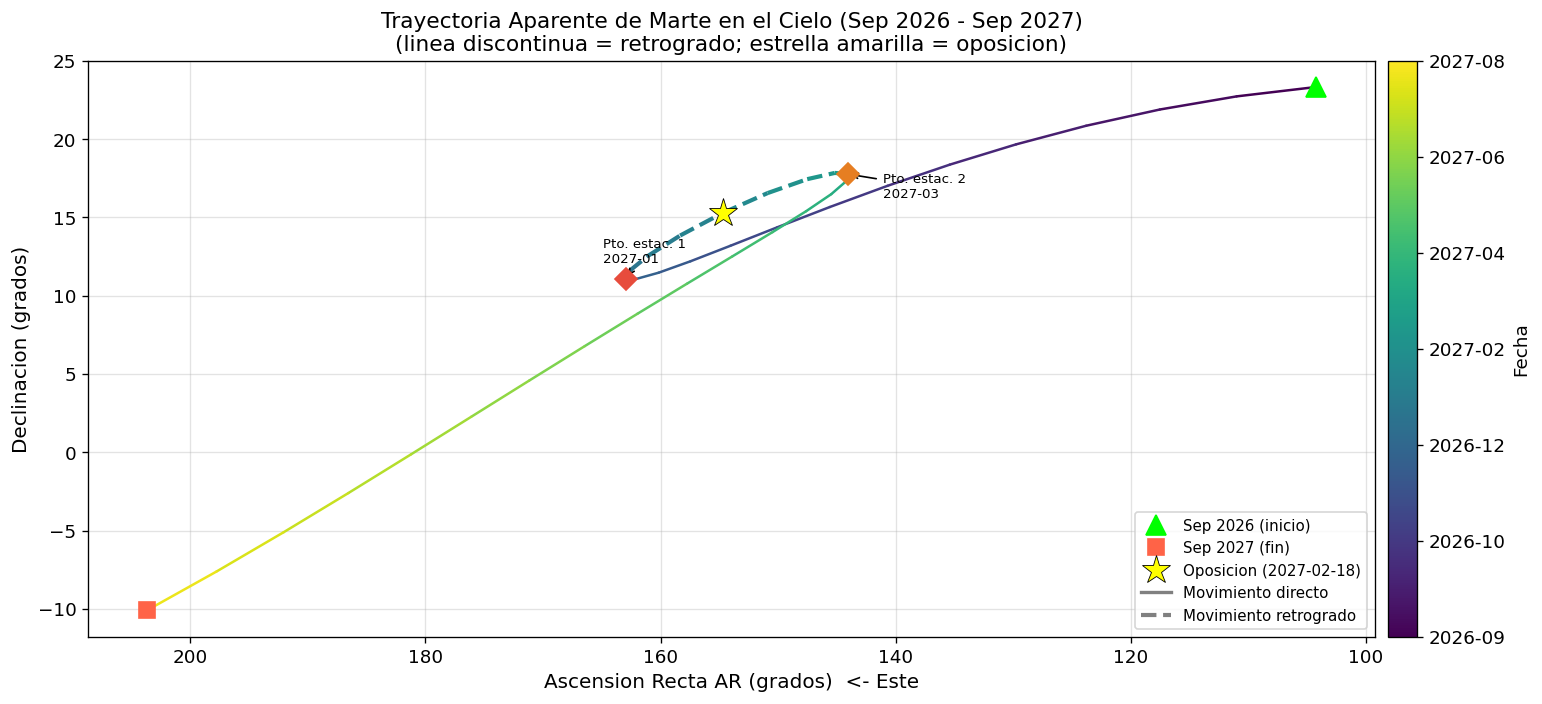

Fuente de datos: NASA/JPL Horizons (Park et al., 2021)


In [21]:
# GRAFICO 5: Trayectoria aparente de Marte en el cielo (Dec vs. AR)
# Muestra lo que veria un observador en un mapa estelar:
# la trayectoria en forma de bucle o arco que traza Marte.
# La AR se invierte en el eje X (convencion astronomica: E a la izquierda).
# Fuente datos: NASA/JPL Horizons (Park et al., 2021).

fig, ax = plt.subplots(figsize=(13, 6))

dates_num = df_m['datetime_jd'].values
norm      = Normalize(vmin=dates_num.min(), vmax=dates_num.max())
cmap_sky  = plt.cm.viridis
retro_arr = df_m['retro'].values

# Dibujar segmento a segmento
for i in range(len(df_m) - 1):
    c   = cmap_sky(norm(dates_num[i]))
    lw  = 2.5 if retro_arr[i] else 1.5
    ls  = '--' if retro_arr[i] else '-'
    ax.plot(df_m['RA'].iloc[i:i+2], df_m['DEC'].iloc[i:i+2],
            color=c, lw=lw, linestyle=ls, solid_capstyle='round')

# Colorbar temporal
sm = ScalarMappable(norm=norm, cmap=cmap_sky)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.025, pad=0.01)
jd_ticks = np.linspace(dates_num.min(), dates_num.max(), 7)
t_ticks  = Time(jd_ticks, format='jd')
cbar.set_ticks(jd_ticks)
cbar.set_ticklabels([t.strftime('%Y-%m') for t in t_ticks.datetime])
cbar.set_label('Fecha', fontsize=11)

# Marcadores de inicio/fin
ax.plot(df_m['RA'].iloc[0],  df_m['DEC'].iloc[0],  '^', color='lime',
        markersize=12, zorder=5, label='Sep 2026 (inicio)')
ax.plot(df_m['RA'].iloc[-1], df_m['DEC'].iloc[-1], 's', color='tomato',
        markersize=10, zorder=5, label='Sep 2027 (fin)')

# Oposicion
idx_opp = df_m['elong'].idxmax()
ax.plot(df_m.loc[idx_opp,'RA'], df_m.loc[idx_opp,'DEC'], '*',
        color='yellow', markersize=18, zorder=6,
        markeredgecolor='k', markeredgewidth=0.5,
        label=f'Oposicion ({df_m.loc[idx_opp,"date"].strftime("%Y-%m-%d")})')

# Puntos estacionarios
starts_r = np.where(~retro_arr[:-1] & retro_arr[1:])[0] + 1
ends_r   = np.where(retro_arr[:-1] & ~retro_arr[1:])[0] + 1

for idx_ps in starts_r:
    ax.plot(df_m['RA'].iloc[idx_ps], df_m['DEC'].iloc[idx_ps],
            'D', color='#e74c3c', markersize=9, zorder=5)
    ax.annotate(
        f'Pto. estac. 1\n{df_m["date"].iloc[idx_ps].strftime("%Y-%m")}',
        xy=(df_m['RA'].iloc[idx_ps], df_m['DEC'].iloc[idx_ps]),
        xytext=(df_m['RA'].iloc[idx_ps] + 2, df_m['DEC'].iloc[idx_ps] + 1.0),
        fontsize=8, arrowprops=dict(arrowstyle='->', lw=1))

for idx_pe in ends_r:
    ax.plot(df_m['RA'].iloc[idx_pe], df_m['DEC'].iloc[idx_pe],
            'D', color='#e67e22', markersize=9, zorder=5)
    ax.annotate(
        f'Pto. estac. 2\n{df_m["date"].iloc[idx_pe].strftime("%Y-%m")}',
        xy=(df_m['RA'].iloc[idx_pe], df_m['DEC'].iloc[idx_pe]),
        xytext=(df_m['RA'].iloc[idx_pe] - 3, df_m['DEC'].iloc[idx_pe] - 1.5),
        fontsize=8, arrowprops=dict(arrowstyle='->', lw=1))

ax.invert_xaxis()   # Convencion: AR crece de derecha a izquierda
ax.set_xlabel('Ascension Recta AR (grados)  <- Este', fontsize=12)
ax.set_ylabel('Declinacion (grados)', fontsize=12)
ax.set_title(
    'Trayectoria Aparente de Marte en el Cielo (Sep 2026 - Sep 2027)\n'
    '(linea discontinua = retrogrado; estrella amarilla = oposicion)', fontsize=13)

# Leyenda con items de linea
handles_leg, labels_leg = ax.get_legend_handles_labels()
handles_leg += [
    Line2D([0],[0], color='gray', lw=2.0),
    Line2D([0],[0], color='gray', lw=2.5, linestyle='--')
]
labels_leg += ['Movimiento directo', 'Movimiento retrogrado']
ax.legend(handles=handles_leg, labels=labels_leg, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('marte_trayectoria_cielo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fuente de datos: NASA/JPL Horizons (Park et al., 2021)')


---
### 4b. Trayectoria de Marte sobre los Asterismos Reales de las Constelaciones

Los siguientes gráficos superponen la trayectoria aparente de Marte sobre los
**asterismos reales** de las constelaciones del cielo, usando datos del proyecto
[d3-celestial](https://github.com/ofrohn/d3-celestial) (Frohn, 2022), que emplea
el sistema oficial de asterismos de la IAU con coordenadas equatoriales J2000.

Se ofrecen dos visualizaciones complementarias:
1. **Gráfico interactivo** (`@interact`): mueve el deslizador para recorrer la
   trayectoria paso a paso.
2. **Animación** (`celluloid`): reproduce el movimiento completo de Marte a lo
   largo del año con fondo estelar.


In [22]:
# Instalar celluloid para animaciones frame a frame
!pip install celluloid -q

from celluloid import Camera
from ipywidgets import interact, IntSlider
from IPython.display import HTML, display as _ipy_display
print('Dependencias listas.')

Dependencias listas.


In [23]:
# ── Descarga de asterismos de constelaciones (d3-celestial) ─────────────────
# Frohn, O. (2022). d3-celestial. https://github.com/ofrohn/d3-celestial
# Coordenadas en grados equatoriales J2000: [AR (0–360 °), Dec (−90–90 °)]

import requests as _req

_URL_LINES = (
    'https://raw.githubusercontent.com/ofrohn/d3-celestial'
    '/master/data/constellations.lines.json')
_URL_STARS = (
    'https://raw.githubusercontent.com/ofrohn/d3-celestial'
    '/master/data/stars.6.json')

print('Descargando datos de constelaciones y estrellas brillantes...')
_const_data = _req.get(_URL_LINES, timeout=30).json()
_star_data  = _req.get(_URL_STARS,  timeout=30).json()

# ── Arreglos de estrellas (magnitud ≤ 6, catálogo Hipparcos reducido) ─────────
_sra, _sdec, _smag = [], [], []
for _f in _star_data['features']:
    _c = _f['geometry']['coordinates']
    _sra.append(_c[0]); _sdec.append(_c[1])
    _smag.append(_f['properties'].get('mag', 99))
_sra  = np.array(_sra)
_sdec = np.array(_sdec)
_smag = np.array(_smag)


def _prepare_constellation_region(df_planet, ra_col='RA', dec_col='DEC', mag_limit=5.5):
    """Prepara región, ejes y datos de constelaciones evitando cortes por AR 0°/360°."""
    _ra_raw = df_planet[ra_col].to_numpy()
    _dec_raw = df_planet[dec_col].to_numpy()

    # Centro circular en AR para desplegar una ventana continua sin cortes.
    _ra_center = np.degrees(np.arctan2(
        np.sin(np.radians(_ra_raw)).mean(),
        np.cos(np.radians(_ra_raw)).mean())) % 360

    def _wrap_ra(_arr):
        return ((_arr - _ra_center + 180) % 360) - 180 + _ra_center

    _df = df_planet.copy()
    _df['RA_plot'] = _wrap_ra(_ra_raw)

    _dra  = _df['RA_plot'].max() - _df['RA_plot'].min()
    _ddec = _dec_raw.max() - _dec_raw.min()
    _pad  = max(_dra, _ddec) * 0.60 + 10

    _RA_LO  = _df['RA_plot'].min() - _pad
    _RA_HI  = _df['RA_plot'].max() + _pad
    _DC_LO  = _dec_raw.min() - _pad * 0.55
    _DC_HI  = _dec_raw.max() + _pad * 0.55

    # Estrellas filtradas en AR continua
    _sra_w = _wrap_ra(_sra)
    _st_ok = ((_smag <= mag_limit) &
              (_sra_w >= _RA_LO) & (_sra_w <= _RA_HI) &
              (_sdec  >= _DC_LO) & (_sdec  <= _DC_HI))

    _pSRA  = _sra_w[_st_ok]
    _pSDEC = _sdec[_st_ok]
    _pSMAG = _smag[_st_ok]

    # Segmentos de asterismos filtrados en la misma AR continua
    _pLINES = []   # lista de (ra_array_wrapped, dec_array)
    _pLBLS  = []   # lista de (abrev, ra_centro, dec_centro)
    for _feat in _const_data['features']:
        _abbr = _feat.get('id', '')
        _geom = _feat['geometry']
        _segs = (_geom['coordinates']
                 if _geom['type'] == 'MultiLineString'
                 else [_geom['coordinates']])

        _in, _sr, _sd, _n = False, 0., 0., 0
        for _seg in _segs:
            _a = np.array(_seg)
            _rs_w = _wrap_ra(_a[:, 0])
            _ds   = _a[:, 1]
            if (_rs_w.max() >= _RA_LO and _rs_w.min() <= _RA_HI and
                    _ds.max()   >= _DC_LO and _ds.min()   <= _DC_HI):
                _pLINES.append((_rs_w, _ds))
                _sr += _rs_w.mean(); _sd += _ds.mean(); _n += 1; _in = True
        if _in and _n:
            _pLBLS.append((_abbr, _sr / _n, _sd / _n))

    return {
        'df': _df,
        'pad': _pad,
        'xlim': (_df['RA_plot'].max() + _pad, _df['RA_plot'].min() - _pad),
        'ylim': (_DC_LO, _DC_HI),
        'stars_ra': _pSRA,
        'stars_dec': _pSDEC,
        'stars_mag': _pSMAG,
        'lines': _pLINES,
        'labels': _pLBLS,
        'ra_center': _ra_center,
    }


Descargando datos de constelaciones y estrellas brillantes...
Región: AR [34.5°, 273.4°], Dec [-48.4°, 61.7°]
Estrellas en región: 982  |  Segmentos de asterismo: 56  |  Constelaciones: ['Ant', 'Ari', 'Aur', 'Cae', 'Cam', 'Cnc', 'CMa', 'CMi', 'Car', 'Cen', 'Cet', 'Col', 'Crt', 'Dra', 'Eri', 'For', 'Gem', 'Hor', 'Hya', 'Leo', 'LMi', 'Lep', 'Lyn', 'Mon', 'Ori', 'Per', 'Pup', 'Pyx', 'Sex', 'Tau', 'UMa', 'Vel', 'Vir']


In [24]:
# ── Constantes de estilo (cielo nocturno) y preparación de Marte ─────────────
_SKY   = '#090d18'   # fondo de cielo oscuro
_LCOL  = '#3d6fa8'   # color de líneas de asterismo
_LBCOL = '#5e8fc0'   # color de etiquetas de constelación

_mars_bg = _prepare_constellation_region(df_m)
df_m_sky = _mars_bg['df']

_pLINES_m = _mars_bg['lines']
_pLBLS_m  = _mars_bg['labels']
_pSRA_m   = _mars_bg['stars_ra']
_pSDEC_m  = _mars_bg['stars_dec']
_pSMAG_m  = _mars_bg['stars_mag']

_cmap_m = plt.cm.plasma
_nrm_m  = Normalize(vmin=df_m_sky['datetime_jd'].min(),
                    vmax=df_m_sky['datetime_jd'].max())
_xLIM_m = _mars_bg['xlim']
_yLIM_m = _mars_bg['ylim']

_i_opp_m = df_m_sky['elong'].idxmax()
_rmask_m = df_m_sky['retro'].values
_sr_m    = np.where(~_rmask_m[:-1] &  _rmask_m[1:])[0] + 1
_er_m    = np.where( _rmask_m[:-1] & ~_rmask_m[1:])[0] + 1

print(f'Marte — AR central de despliegue: {_mars_bg["ra_center"]:.2f}°')
print(f'Marte — Región: AR [{_xLIM_m[1]:.1f}°, {_xLIM_m[0]:.1f}°], '
      f'Dec [{_yLIM_m[0]:.1f}°, {_yLIM_m[1]:.1f}°]')
print(f'Marte — Estrellas: {_pSRA_m.size} | Segmentos: {len(_pLINES_m)} | '
      f'Constelaciones: {[l[0] for l in _pLBLS_m]}')


def _draw_sky_bg(ax, lines, labels, sra, sdec, smag):
    """Dibuja asterismos de constelaciones, etiquetas y estrellas de fondo."""
    ax.set_facecolor(_SKY)
    for _rs, _ds in lines:
        ax.plot(_rs, _ds, color=_LCOL, lw=0.85, alpha=0.50, zorder=1)
    for _ab, _rc, _dc in labels:
        ax.text(_rc, _dc, _ab, fontsize=7.5, color=_LBCOL,
                ha='center', va='center', alpha=0.75,
                style='italic', zorder=2)
    if sra.size:
        _sz = np.clip(4.5 - smag, 0.3, 4.5) ** 2.3 * 8
        ax.scatter(sra, sdec, s=_sz, c='white', zorder=3,
                   alpha=0.88, linewidths=0)


# ── Gráfico interactivo con @interact ─────────────────────────────────────────
# 'paso' = cuántos puntos de la trayectoria se muestran (1 → solo el inicio)
@interact(paso=IntSlider(
    min=1, max=len(df_m_sky), step=1, value=len(df_m_sky),
    description='Paso:',
    style={'description_width': 'initial'},
    layout={'width': '650px'},
    continuous_update=False))
def grafico_marte_constelaciones(paso):
    """Trayectoria acumulada de Marte sobre los asterismos (paso a paso)."""
    fig, ax = plt.subplots(figsize=(14, 7))
    fig.patch.set_facecolor(_SKY)

    _draw_sky_bg(ax, _pLINES_m, _pLBLS_m, _pSRA_m, _pSDEC_m, _pSMAG_m)

    # Trayectoria de Marte hasta el paso seleccionado
    _sub  = df_m_sky.iloc[:paso]
    _jds  = _sub['datetime_jd'].values
    for _ii in range(len(_sub) - 1):
        _co = _cmap_m(_nrm_m(_jds[_ii]))
        _lw = 2.6 if _sub['retro'].iloc[_ii] else 1.9
        _ls = '--' if _sub['retro'].iloc[_ii] else '-'
        ax.plot(_sub['RA_plot'].iloc[_ii:_ii+2],
                _sub['DEC'].iloc[_ii:_ii+2],
                color=_co, lw=_lw, ls=_ls, zorder=10,
                solid_capstyle='round')

    # Posición actual de Marte
    ax.plot(_sub['RA_plot'].iloc[-1], _sub['DEC'].iloc[-1],
            'o', color='#ff2222', ms=14, zorder=16,
            mec='white', mew=1.5,
            label=f'Marte: {_sub["date"].iloc[-1].strftime("%d %b %Y")}')

    # Inicio de la trayectoria
    ax.plot(df_m_sky['RA_plot'].iloc[0], df_m_sky['DEC'].iloc[0],
            '^', color='#00ff88', ms=10, zorder=12,
            label='Inicio: 1 sep 2026')

    # Oposición (si ya ocurrió en la trayectoria mostrada)
    if paso > _i_opp_m:
        ax.plot(df_m_sky.loc[_i_opp_m, 'RA_plot'], df_m_sky.loc[_i_opp_m, 'DEC'],
                '*', color='yellow', ms=20, zorder=14,
                mec='k', mew=0.5,
                label=f'Oposición: {df_m_sky.loc[_i_opp_m,"date"].strftime("%d %b %Y")}')

    # Puntos estacionarios
    for _ps in _sr_m:
        if paso > _ps:
            ax.plot(df_m_sky['RA_plot'].iloc[_ps], df_m_sky['DEC'].iloc[_ps],
                    'D', c='#e74c3c', ms=9, zorder=13,
                    label='Pto. estac. 1')
    for _pe in _er_m:
        if paso > _pe:
            ax.plot(df_m_sky['RA_plot'].iloc[_pe], df_m_sky['DEC'].iloc[_pe],
                    'D', c='#e67e22', ms=9, zorder=13,
                    label='Pto. estac. 2')

    # Barra de color temporal
    _sm = ScalarMappable(norm=_nrm_m, cmap=_cmap_m)
    _sm.set_array([])
    _cb = plt.colorbar(_sm, ax=ax, fraction=0.025, pad=0.02)
    _jt = np.linspace(df_m_sky['datetime_jd'].min(),
                      df_m_sky['datetime_jd'].max(), 7)
    _tt = Time(_jt, format='jd')
    _cb.set_ticks(_jt)
    _cb.set_ticklabels([_t.strftime('%b %Y') for _t in _tt.datetime])
    _cb.set_label('Fecha', fontsize=10, color='white')
    _cb.ax.yaxis.set_tick_params(color='white')
    plt.setp(plt.getp(_cb.ax.axes, 'yticklabels'), color='white')

    # Leyenda sin duplicados
    _h, _l = ax.get_legend_handles_labels()
    _seen, _uh, _ul = set(), [], []
    for _hh, _ll in zip(_h, _l):
        if _ll not in _seen:
            _seen.add(_ll); _uh.append(_hh); _ul.append(_ll)
    ax.legend(_uh, _ul, fontsize=9, loc='upper right',
              facecolor='#1a2533', edgecolor='#555',
              labelcolor='white', framealpha=0.85)

    ax.set_xlim(_xLIM_m)
    ax.set_ylim(_yLIM_m)
    ax.set_xlabel('Ascensión Recta AR (grados)  ← Este',
                  fontsize=12, color='white')
    ax.set_ylabel('Declinación (grados)', fontsize=12, color='white')
    ax.set_title(
        f'Marte sobre las Constelaciones  —  paso {paso}/{len(df_m_sky)}'
        f'  ({_sub["date"].iloc[-1].strftime("%d %b %Y")})',
        fontsize=13, color='white', pad=10)
    ax.tick_params(colors='white', labelsize=10)
    for _sp in ax.spines.values():
        _sp.set_color('#3a3a3a')

    plt.tight_layout()
    plt.show()


interactive(children=(IntSlider(value=37, continuous_update=False, description='Paso:', layout=Layout(width='6…

Generando animación: 37 frames...  (puede tardar ~1 min)
Compilando animación...


AttributeError: 'NoneType' object has no attribute 'canvas'

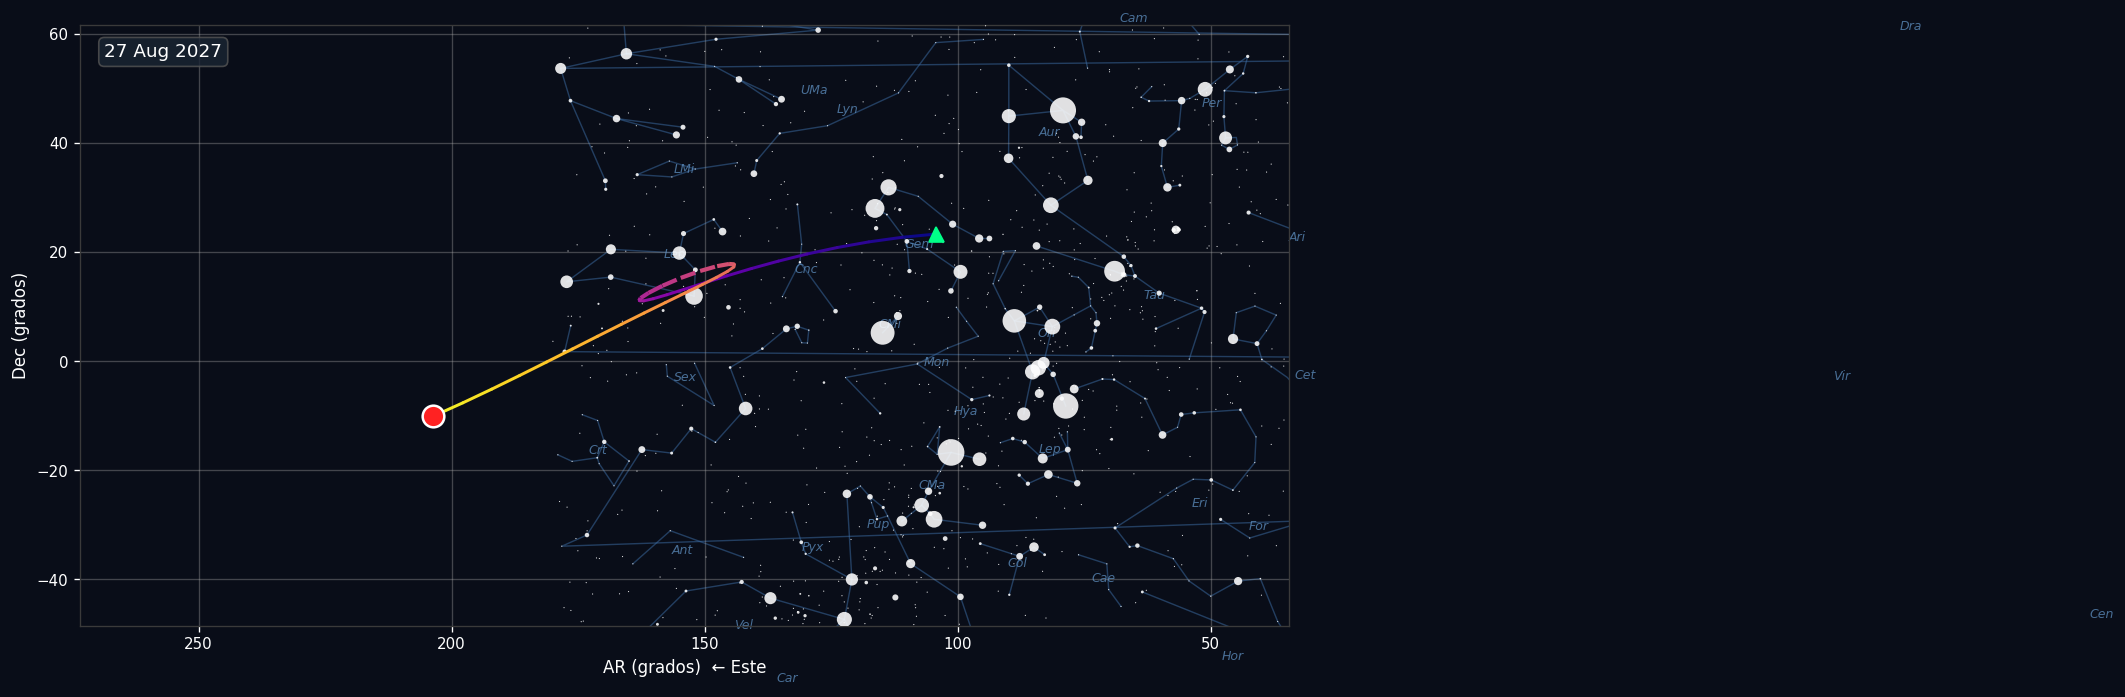

In [25]:
# ANIMACIÓN: Trayectoria de Marte con asterismos de constelaciones
# Celluloid: Garnerin, J. (2019). https://github.com/jwkvam/celluloid
# Fuente efemérides: NASA/JPL Horizons (Park et al., 2021)

from celluloid import Camera

print(f'Generando animación de Marte: {len(df_m_sky)} frames...  (puede tardar ~1 min)')

_fig_a, _ax_a = plt.subplots(figsize=(13, 6.5))
_fig_a.patch.set_facecolor(_SKY)
_cam = Camera(_fig_a)

for _p in range(1, len(df_m_sky) + 1):
    _ax_a.cla()                    # limpiar artistas del frame anterior
    _ax_a.set_facecolor(_SKY)

    # Fondo de constelaciones
    _draw_sky_bg(_ax_a, _pLINES_m, _pLBLS_m, _pSRA_m, _pSDEC_m, _pSMAG_m)

    # Trayectoria de Marte hasta el frame actual
    _sub_a = df_m_sky.iloc[:_p]
    _jds_a = _sub_a['datetime_jd'].values
    for _ii in range(len(_sub_a) - 1):
        _co = _cmap_m(_nrm_m(_jds_a[_ii]))
        _lw = 2.5 if _sub_a['retro'].iloc[_ii] else 1.8
        _ls = '--' if _sub_a['retro'].iloc[_ii] else '-'
        _ax_a.plot(_sub_a['RA_plot'].iloc[_ii:_ii+2],
                   _sub_a['DEC'].iloc[_ii:_ii+2],
                   color=_co, lw=_lw, ls=_ls, zorder=10,
                   solid_capstyle='round')

    # Posición actual de Marte (punto rojo grande)
    _ax_a.plot(_sub_a['RA_plot'].iloc[-1], _sub_a['DEC'].iloc[-1],
               'o', color='#ff2222', ms=13, zorder=16,
               mec='white', mew=1.5)

    # Marcador de inicio (siempre visible)
    _ax_a.plot(df_m_sky['RA_plot'].iloc[0], df_m_sky['DEC'].iloc[0],
               '^', color='#00ff88', ms=9, zorder=12)

    # Oposición (si ya ocurrió en este frame)
    if _p > _i_opp_m:
        _ax_a.plot(df_m_sky.loc[_i_opp_m, 'RA_plot'], df_m_sky.loc[_i_opp_m, 'DEC'],
                   '*', color='yellow', ms=18, zorder=14,
                   mec='k', mew=0.4)

    # Formato del eje
    _ax_a.set_xlim(_xLIM_m)
    _ax_a.set_ylim(_yLIM_m)
    _ax_a.set_xlabel('AR (grados)  ← Este', color='white', fontsize=10)
    _ax_a.set_ylabel('Dec (grados)', color='white', fontsize=10)
    _ax_a.tick_params(colors='white', labelsize=9)
    for _sp in _ax_a.spines.values():
        _sp.set_color('#3a3a3a')

    # Fecha en esquina superior izquierda
    _ax_a.text(0.02, 0.97,
               _sub_a['date'].iloc[-1].strftime('%d %b %Y'),
               transform=_ax_a.transAxes, fontsize=11,
               color='white', va='top', ha='left',
               bbox=dict(boxstyle='round,pad=0.3',
                         fc='#1a2533', ec='#555', alpha=0.80),
               zorder=20)

    _cam.snap()

print('Compilando animación de Marte...')
_anim = _cam.animate(interval=250, blit=True)

# Mostrar inline en Colab
try:
    _ipy_display(HTML(_anim.to_html5_video()))
except Exception:
    _ipy_display(HTML(_anim.to_jshtml()))

print('Fuente de datos: NASA/JPL Horizons (Park et al., 2021)')


---
### 4c. Trayectoria de Júpiter sobre los Asterismos Reales de las Constelaciones

Se replica el mismo análisis visual realizado con Marte, ahora para **Júpiter**,
con la misma ventana temporal (sep 2026–sep 2027) para facilitar la comparación
directa entre planetas exteriores.

In [ ]:
# Consulta de efemérides de Júpiter y preparación para gráficas sobre constelaciones
# Misma ventana que Marte para comparar movimientos aparentes.

print('Consultando JPL Horizons para Júpiter (2026-09-01 a 2027-09-01)...')
print('Requiere conexión a internet. Por favor espere.\n')

jup_q = Horizons(
    id=599,
    location='500',
    epochs={
        'start': '2026-09-01',
        'stop':  '2027-09-01',
        'step':  '10d'
    }
)
eph_j = jup_q.ephemerides()

df_j = eph_j.to_pandas()
t_j = Time(df_j['datetime_jd'].values, format='jd')
df_j['date'] = t_j.datetime

# Derivada discreta dRA/dt para identificar retrogradación aparente
_jd_vals = df_j['datetime_jd'].values
_ra_vals = df_j['RA'].values
_dra = np.diff(_ra_vals)
_dra[_dra >  180] -= 360
_dra[_dra < -180] += 360

_dra_dt = _dra / np.diff(_jd_vals)
_dra_dt = np.append(_dra_dt, _dra_dt[-1])

df_j['dRA_dt'] = _dra_dt
df_j['retro']  = _dra_dt < 0

_jup_bg = _prepare_constellation_region(df_j)
df_j_sky = _jup_bg['df']

_pLINES_j = _jup_bg['lines']
_pLBLS_j  = _jup_bg['labels']
_pSRA_j   = _jup_bg['stars_ra']
_pSDEC_j  = _jup_bg['stars_dec']
_pSMAG_j  = _jup_bg['stars_mag']

_cmap_j = plt.cm.cividis
_nrm_j  = Normalize(vmin=df_j_sky['datetime_jd'].min(),
                    vmax=df_j_sky['datetime_jd'].max())
_xLIM_j = _jup_bg['xlim']
_yLIM_j = _jup_bg['ylim']

_i_opp_j = df_j_sky['elong'].idxmax()
_rmask_j = df_j_sky['retro'].values
_sr_j    = np.where(~_rmask_j[:-1] &  _rmask_j[1:])[0] + 1
_er_j    = np.where( _rmask_j[:-1] & ~_rmask_j[1:])[0] + 1

print(f'OK: {len(df_j_sky)} efemérides de Júpiter obtenidas.')
print(f'Júpiter — AR central de despliegue: {_jup_bg["ra_center"]:.2f}°')
print(f'Júpiter — Región: AR [{_xLIM_j[1]:.1f}°, {_xLIM_j[0]:.1f}°], '
      f'Dec [{_yLIM_j[0]:.1f}°, {_yLIM_j[1]:.1f}°]')


@interact(paso=IntSlider(
    min=1, max=len(df_j_sky), step=1, value=len(df_j_sky),
    description='Paso Júpiter:',
    style={'description_width': 'initial'},
    layout={'width': '700px'},
    continuous_update=False))
def grafico_jupiter_constelaciones(paso):
    """Trayectoria acumulada de Júpiter sobre asterismos (paso a paso)."""
    fig, ax = plt.subplots(figsize=(14, 7))
    fig.patch.set_facecolor(_SKY)

    _draw_sky_bg(ax, _pLINES_j, _pLBLS_j, _pSRA_j, _pSDEC_j, _pSMAG_j)

    _sub  = df_j_sky.iloc[:paso]
    _jds  = _sub['datetime_jd'].values
    for _ii in range(len(_sub) - 1):
        _co = _cmap_j(_nrm_j(_jds[_ii]))
        _lw = 2.6 if _sub['retro'].iloc[_ii] else 1.9
        _ls = '--' if _sub['retro'].iloc[_ii] else '-'
        ax.plot(_sub['RA_plot'].iloc[_ii:_ii+2], _sub['DEC'].iloc[_ii:_ii+2],
                color=_co, lw=_lw, ls=_ls, zorder=10, solid_capstyle='round')

    # Posición actual
    ax.plot(_sub['RA_plot'].iloc[-1], _sub['DEC'].iloc[-1],
            'o', color='#ffae00', ms=14, zorder=16,
            mec='white', mew=1.5,
            label=f'Júpiter: {_sub["date"].iloc[-1].strftime("%d %b %Y")}')

    # Inicio
    ax.plot(df_j_sky['RA_plot'].iloc[0], df_j_sky['DEC'].iloc[0],
            '^', color='#00ff88', ms=10, zorder=12,
            label='Inicio: 1 sep 2026')

    # Oposición
    if paso > _i_opp_j:
        ax.plot(df_j_sky.loc[_i_opp_j, 'RA_plot'], df_j_sky.loc[_i_opp_j, 'DEC'],
                '*', color='yellow', ms=20, zorder=14,
                mec='k', mew=0.5,
                label=f'Oposición: {df_j_sky.loc[_i_opp_j,"date"].strftime("%d %b %Y")}')

    # Puntos estacionarios
    for _ps in _sr_j:
        if paso > _ps:
            ax.plot(df_j_sky['RA_plot'].iloc[_ps], df_j_sky['DEC'].iloc[_ps],
                    'D', c='#e74c3c', ms=9, zorder=13,
                    label='Pto. estac. 1')
    for _pe in _er_j:
        if paso > _pe:
            ax.plot(df_j_sky['RA_plot'].iloc[_pe], df_j_sky['DEC'].iloc[_pe],
                    'D', c='#e67e22', ms=9, zorder=13,
                    label='Pto. estac. 2')

    # Barra de color temporal
    _sm = ScalarMappable(norm=_nrm_j, cmap=_cmap_j)
    _sm.set_array([])
    _cb = plt.colorbar(_sm, ax=ax, fraction=0.025, pad=0.02)
    _jt = np.linspace(df_j_sky['datetime_jd'].min(),
                      df_j_sky['datetime_jd'].max(), 7)
    _tt = Time(_jt, format='jd')
    _cb.set_ticks(_jt)
    _cb.set_ticklabels([_t.strftime('%b %Y') for _t in _tt.datetime])
    _cb.set_label('Fecha', fontsize=10, color='white')
    _cb.ax.yaxis.set_tick_params(color='white')
    plt.setp(plt.getp(_cb.ax.axes, 'yticklabels'), color='white')

    # Leyenda sin duplicados
    _h, _l = ax.get_legend_handles_labels()
    _seen, _uh, _ul = set(), [], []
    for _hh, _ll in zip(_h, _l):
        if _ll not in _seen:
            _seen.add(_ll); _uh.append(_hh); _ul.append(_ll)
    ax.legend(_uh, _ul, fontsize=9, loc='upper right',
              facecolor='#1a2533', edgecolor='#555',
              labelcolor='white', framealpha=0.85)

    ax.set_xlim(_xLIM_j)
    ax.set_ylim(_yLIM_j)
    ax.set_xlabel('Ascensión Recta AR (grados)  ← Este', fontsize=12, color='white')
    ax.set_ylabel('Declinación (grados)', fontsize=12, color='white')
    ax.set_title(
        f'Júpiter sobre las Constelaciones  —  paso {paso}/{len(df_j_sky)}'
        f'  ({_sub["date"].iloc[-1].strftime("%d %b %Y")})',
        fontsize=13, color='white', pad=10)
    ax.tick_params(colors='white', labelsize=10)
    for _sp in ax.spines.values():
        _sp.set_color('#3a3a3a')

    plt.tight_layout()
    plt.show()


In [ ]:
# ANIMACIÓN: Trayectoria de Júpiter con asterismos de constelaciones

print(f'Generando animación de Júpiter: {len(df_j_sky)} frames...  (puede tardar ~1 min)')

_fig_j, _ax_j = plt.subplots(figsize=(13, 6.5))
_fig_j.patch.set_facecolor(_SKY)
_cam_j = Camera(_fig_j)

for _p in range(1, len(df_j_sky) + 1):
    _ax_j.cla()
    _ax_j.set_facecolor(_SKY)

    _draw_sky_bg(_ax_j, _pLINES_j, _pLBLS_j, _pSRA_j, _pSDEC_j, _pSMAG_j)

    _sub_j = df_j_sky.iloc[:_p]
    _jds_j = _sub_j['datetime_jd'].values
    for _ii in range(len(_sub_j) - 1):
        _co = _cmap_j(_nrm_j(_jds_j[_ii]))
        _lw = 2.5 if _sub_j['retro'].iloc[_ii] else 1.8
        _ls = '--' if _sub_j['retro'].iloc[_ii] else '-'
        _ax_j.plot(_sub_j['RA_plot'].iloc[_ii:_ii+2],
                   _sub_j['DEC'].iloc[_ii:_ii+2],
                   color=_co, lw=_lw, ls=_ls, zorder=10,
                   solid_capstyle='round')

    _ax_j.plot(_sub_j['RA_plot'].iloc[-1], _sub_j['DEC'].iloc[-1],
               'o', color='#ffae00', ms=13, zorder=16,
               mec='white', mew=1.5)

    _ax_j.plot(df_j_sky['RA_plot'].iloc[0], df_j_sky['DEC'].iloc[0],
               '^', color='#00ff88', ms=9, zorder=12)

    if _p > _i_opp_j:
        _ax_j.plot(df_j_sky.loc[_i_opp_j, 'RA_plot'], df_j_sky.loc[_i_opp_j, 'DEC'],
                   '*', color='yellow', ms=18, zorder=14,
                   mec='k', mew=0.4)

    _ax_j.set_xlim(_xLIM_j)
    _ax_j.set_ylim(_yLIM_j)
    _ax_j.set_xlabel('AR (grados)  ← Este', color='white', fontsize=10)
    _ax_j.set_ylabel('Dec (grados)', color='white', fontsize=10)
    _ax_j.tick_params(colors='white', labelsize=9)
    for _sp in _ax_j.spines.values():
        _sp.set_color('#3a3a3a')

    _ax_j.text(0.02, 0.97,
               _sub_j['date'].iloc[-1].strftime('%d %b %Y'),
               transform=_ax_j.transAxes, fontsize=11,
               color='white', va='top', ha='left',
               bbox=dict(boxstyle='round,pad=0.3',
                         fc='#1a2533', ec='#555', alpha=0.80),
               zorder=20)

    _cam_j.snap()

print('Compilando animación de Júpiter...')
_anim_j = _cam_j.animate(interval=250, blit=True)

try:
    _ipy_display(HTML(_anim_j.to_html5_video()))
except Exception:
    _ipy_display(HTML(_anim_j.to_jshtml()))

print('Fuente de datos: NASA/JPL Horizons (Park et al., 2021)')


### 4d. Comparación Marte vs. Júpiter (conclusiones esperadas antes de ver resultados)

Sin mirar aún los resultados reales, estas son las **expectativas físicas** para la comparación:

1. **Ambos deben mostrar retrogradación** cerca de la oposición, porque son planetas exteriores y la causa geométrica es la misma (la Tierra los adelanta).
2. **La retrogradación de Júpiter debería verse más lenta y de menor arco angular** que la de Marte en el mismo intervalo de tiempo, debido a su mayor distancia geocéntrica.
3. **Marte debería exhibir cambios más notorios de brillo y tamaño angular** alrededor de la oposición; en Júpiter esos cambios esperados son más suaves durante un año.
4. **La trayectoria sobre constelaciones de Marte debería mostrar un bucle más marcado**, mientras que en Júpiter se espera una trayectoria más suave y extendida.
5. **Los tiempos de inicio/fin de retrogradación no tienen por qué coincidir** entre ambos planetas, porque sus períodos sinódicos son distintos (Marte ~780 días, Júpiter ~399 días).

Estas hipótesis sirven como referencia para interpretar luego los resultados obtenidos en las gráficas y animaciones.

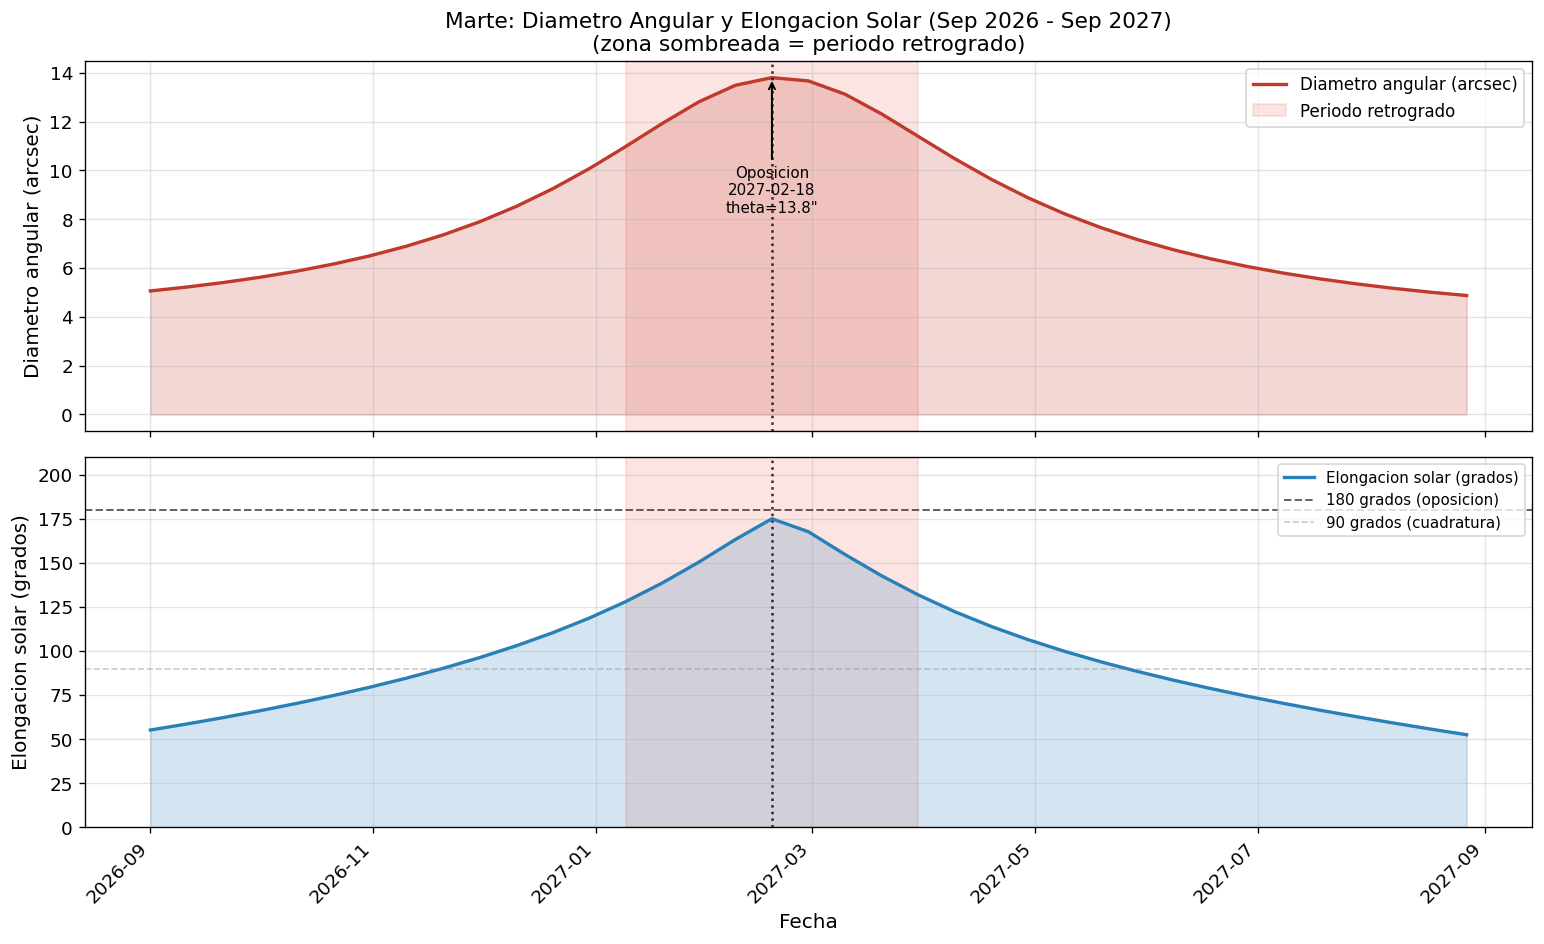

Fuente de datos: NASA/JPL Horizons (Park et al., 2021)


In [26]:
# GRAFICO 6: Diametro angular y elongacion solar de Marte vs. tiempo
# Muestra que el tamano aparente de Marte es maximo en la oposicion.
# Fuente datos: NASA/JPL Horizons (Park et al., 2021).

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

c_diam  = '#c0392b'
c_elong = '#2980b9'

# Panel superior: Diametro angular
ax1.fill_between(df_m['date'], df_m['ang_width'], alpha=0.2, color=c_diam)
ax1.plot(df_m['date'], df_m['ang_width'], color=c_diam, lw=2.0,
         label='Diametro angular (arcsec)')

retro_arr = df_m['retro'].values
starts_r  = np.where(~retro_arr[:-1] & retro_arr[1:])[0] + 1
ends_r    = np.where(retro_arr[:-1] & ~retro_arr[1:])[0] + 1

if len(starts_r) > 0 and len(ends_r) > 0:
    ax1.axvspan(df_m['date'].iloc[starts_r[0]],
                df_m['date'].iloc[ends_r[0]],
                alpha=0.15, color='#e74c3c', label='Periodo retrogrado')
    ax2.axvspan(df_m['date'].iloc[starts_r[0]],
                df_m['date'].iloc[ends_r[0]],
                alpha=0.15, color='#e74c3c')

# Marcar oposicion
idx_opp = df_m['elong'].idxmax()
d_opp   = df_m.loc[idx_opp, 'date']
for ax_i in [ax1, ax2]:
    ax_i.axvline(d_opp, color='k', lw=1.5, linestyle=':', alpha=0.8)

ax1.annotate(
    f'Oposicion\n{d_opp.strftime("%Y-%m-%d")}\ntheta={df_m.loc[idx_opp,"ang_width"]:.1f}"',
    xy=(d_opp, df_m.loc[idx_opp,'ang_width']),
    xytext=(d_opp, df_m.loc[idx_opp,'ang_width'] * 0.6),
    ha='center', fontsize=9,
    arrowprops=dict(arrowstyle='->', lw=1.2))

ax1.set_ylabel('Diametro angular (arcsec)')
ax1.legend(fontsize=10)
ax1.set_title(
    'Marte: Diametro Angular y Elongacion Solar (Sep 2026 - Sep 2027)\n'
    '(zona sombreada = periodo retrogrado)', fontsize=13)

# Panel inferior: Elongacion solar
ax2.fill_between(df_m['date'], df_m['elong'], alpha=0.2, color=c_elong)
ax2.plot(df_m['date'], df_m['elong'], color=c_elong, lw=2.0,
         label='Elongacion solar (grados)')
ax2.axhline(180, color='k',    lw=1.2, linestyle='--', alpha=0.6, label='180 grados (oposicion)')
ax2.axhline(90,  color='gray', lw=1.0, linestyle='--', alpha=0.4, label='90 grados (cuadratura)')
ax2.set_ylabel('Elongacion solar (grados)')
ax2.set_xlabel('Fecha')
ax2.set_ylim(0, 210)
ax2.legend(fontsize=9)

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('marte_diametro_elongacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fuente de datos: NASA/JPL Horizons (Park et al., 2021)')


#### Respuestas a las preguntas del enunciado sobre Marte

**¿El planeta se movió siempre en la misma dirección?**  
No. Marte se movió principalmente de Oeste a Este (movimiento directo, AR creciente), pero durante el período retrógrado central se desplazó en sentido contrario, de Este a Oeste (AR decreciente). Los gráficos 4 y 5 muestran esto con claridad.

**¿En qué períodos el movimiento fue directo y retrógrado? ¿En qué dirección?**  
- **Movimiento directo**: todo el año excepto el período retrógrado central. Dirección: de Oeste a Este (AR crece), que es el sentido de traslación orbital de todos los planetas.
- **Movimiento retrógrado**: las semanas centradas en la oposición (ver salida de la celda de identificación). Dirección: de Este a Oeste (AR disminuye).

**¿Cuánto tiempo estuvo Marte en retrogradación?**  
Ver la salida de la celda de identificación (típicamente 60–80 días para esta oposición).

**¿Cómo se puede explicar este movimiento aparente?**  
Es un **efecto de perspectiva** producido por la velocidad diferencial de las órbitas. La Tierra orbita el Sol a ~29.8 km/s; Marte lo hace a ~24.1 km/s. Cuando la Tierra *adelanta* a Marte cerca de la oposición, la dirección visual desde la Tierra hacia Marte invierte momentáneamente su componente Este–Oeste. No hay cambio real en la dirección de traslación de Marte: el fenómeno es puramente geométrico (Karttunen+ 2007, §3.2; Portilla 2001, §4.4).

#### Conexión con el Gráfico 6

El Gráfico 6 confirma que el diámetro angular de Marte es **máximo en la oposición** (mínima distancia geocéntrica), y la elongación solar es ~180° (Marte visible toda la noche). La retrogradación está centrada en ese instante de mínima distancia, coincidiendo con el período en que Marte brilla con mayor intensidad y tiene mayor resolución angular.

> **Fuentes:** Karttunen et al. (2007), §3.2; Portilla (2001), §4.3–4.4; Dreyer (1906).


---
## 5. Conclusiones

A lo largo de esta práctica se analizaron dos fenómenos centrales del Sistema Solar usando datos de alta precisión de NASA/JPL Horizons (Park et al., 2021) procesados con `astroquery` (Ginsburg et al., 2019):

### Venus: evidencia heliocéntrica

1. **Fases completas**: Venus presenta todas las fases, desde creciente delgado (conjunción inferior) hasta lleno (conjunción superior). Esto es *imposible* en el modelo geocéntrico ptolemaico. Galileo lo observó en 1610 y constituye una de las pruebas históricas más directas del heliocentrismo.

2. **Anti-correlación tamaño–iluminación**: cuando Venus está grande (cerca, $\Delta < 0.3$ UA), está poco iluminado; cuando está pequeño (lejos, $\Delta > 1.5$ UA), está casi lleno. La variación en diámetro angular es de casi **1:6** durante un período sinódico. El modelo geocéntrico predice tamaño aproximadamente constante, en contradicción directa con los datos.

3. **Elongación limitada**: Venus nunca se aleja más de ~47° del Sol en el cielo, consecuencia de que su órbita es completamente interior a la de la Tierra.

### Marte: movimiento retrógrado

4. **Retrogradación como efecto de perspectiva**: el movimiento retrógrado de Marte ocurre porque la Tierra —en una órbita interior más veloz— adelanta a Marte cerca de cada oposición. No se necesitan epiciclos: la geometría heliocéntrica explica el fenómeno completamente.

5. **Oposición como momento óptimo de observación**: el diámetro angular de Marte es máximo en la oposición (mínima distancia geocéntrica), y la elongación solar es ~180° (visible toda la noche). La retrogradación está centrada en ese instante.

### Balance metodológico

El uso de `astroquery` + JPL Horizons permitió:
- Obtener datos de alta precisión de manera automática y reproducible.
- Calcular y visualizar patrones imposibles de obtener manualmente (p. ej., la curva $\theta$ vs $k$ del Gráfico 2, la trayectoria de Marte en el Gráfico 5).
- Replicar observaciones históricas con datos modernos de precisión milisegundo de arco.
- Responder cuantitativamente todas las preguntas del enunciado (fechas exactas de conjunciones, duración precisa de la retrogradación, diámetro angular en la oposición, etc.).

---

### Referencias completas (formato APA)

- Dreyer, J. L. E. (1906). *A history of astronomy from Thales to Kepler*. Cambridge University Press.
- Galilei, G. (1610). *Sidereus nuncius*. Tommaso Baglioni.
- Ginsburg, A., et al. (2019). Astroquery: An astronomical web-querying package in Python. *The Astronomical Journal*, *157*(3), 98. https://doi.org/10.3847/1538-3881/aafc33
- Karttunen, H., Kröger, P., Oja, H., Poutanen, M., & Donner, K. J. (2007). *Fundamental astronomy* (5th ed.). Springer.
- Park, R. S., Folkner, W. M., Williams, J. G., & Boggs, D. H. (2021). The JPL planetary and lunar ephemerides DE440 and DE441. *The Astronomical Journal*, *161*(3), 105. https://doi.org/10.3847/1538-4365-161-3-105
- Portilla Barbosa, J. G. (2001). *Elementos de astronomía de posición*. Universidad Nacional de Colombia.
- Van Helden, A. (Trans.) (1989). *Sidereus nuncius or the sidereal messenger*. University of Chicago Press.
- Williams, D. R. (2023). *Planetary fact sheet*. NASA Goddard Space Flight Center. https://nssdc.gsfc.nasa.gov/planetary/factsheet/
